# **RAFKI SAHASIKA RIYUDA**
# **09011182227007**
# **PRAKTIKUM MACHINE LEARNING**

# __WEEK-1 DATA UNDERSTANDING__

## *Data Understanding*

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [8]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Dataset ini berisi **32.581 baris** dan **12 kolom**. Ada 5 kolom numerik (int64), 3 kolom desimal (float64), dan 4 kolom kategori (object). Kolom person_emp_length dan loan_int_rate memiliki data yang hilang karena jumlah non-null-nya lebih sedikit dari total data.

In [10]:
df_types = df.dtypes
categorical=df.select_dtypes(include=["object"]).columns
numerical=df.select_dtypes(include=["int","float"]).columns

print("Kolom Kategorikal-nya berjumlah:",len(categorical))
print("Kolom Numerik-nya berjumlah:",len(numerical))

Kolom Kategorikal-nya berjumlah: 4
Kolom Numerik-nya berjumlah: 8


In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


### Menghapus Kolom Duplikat
Untuk itu saya mengeceknya terlebih dahulu kemudian drop kolom yang terduplikasi yang mana berjumlah 165 data. Dan kemudian saya pastikan kembali kolom yang terduplikat.

In [13]:
dataduplikat= df.duplicated().sum()
print("Jumlah data yang duplikat:",(dataduplikat))

Jumlah data yang duplikat: 165


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

0

### Mengisi Missing Value
Pertama saya menjumlahkan **Missing Value** pada masing masing kolom. Diaman terdapat 887 missing value pada kolom person_emp_length dan 3095 pada kolom loan_int_rate. Kemudian untuk mengatasi itu, saya mengisi Missing Value dengan menggunakan median. Dan kemudian saya pastikan kembali Missing Valuenya.

In [16]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [17]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [18]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

### Unique Value


In [19]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

Dari output ini, bisa disimpulkan bahwa dataset ini mengandung kombinasi data numerik kontinu, kategori tetap, serta beberapa variabel biner yang bisa digunakan untuk analisis lebih lanjut.

# __WEEK-2 ANALISIS EKSPLORASI DATASET__

## *Exploratory Data Analysis (EDA)*

In [20]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

Disini dipisahkan terlebih dahulu kolom numerik dan kategorikal untuk memudahkan analisis data, seperti melakukan eksplorasi, visualisasi, atau preprocessing sebelum model machine learning dibuat.

### Correlation Matrix

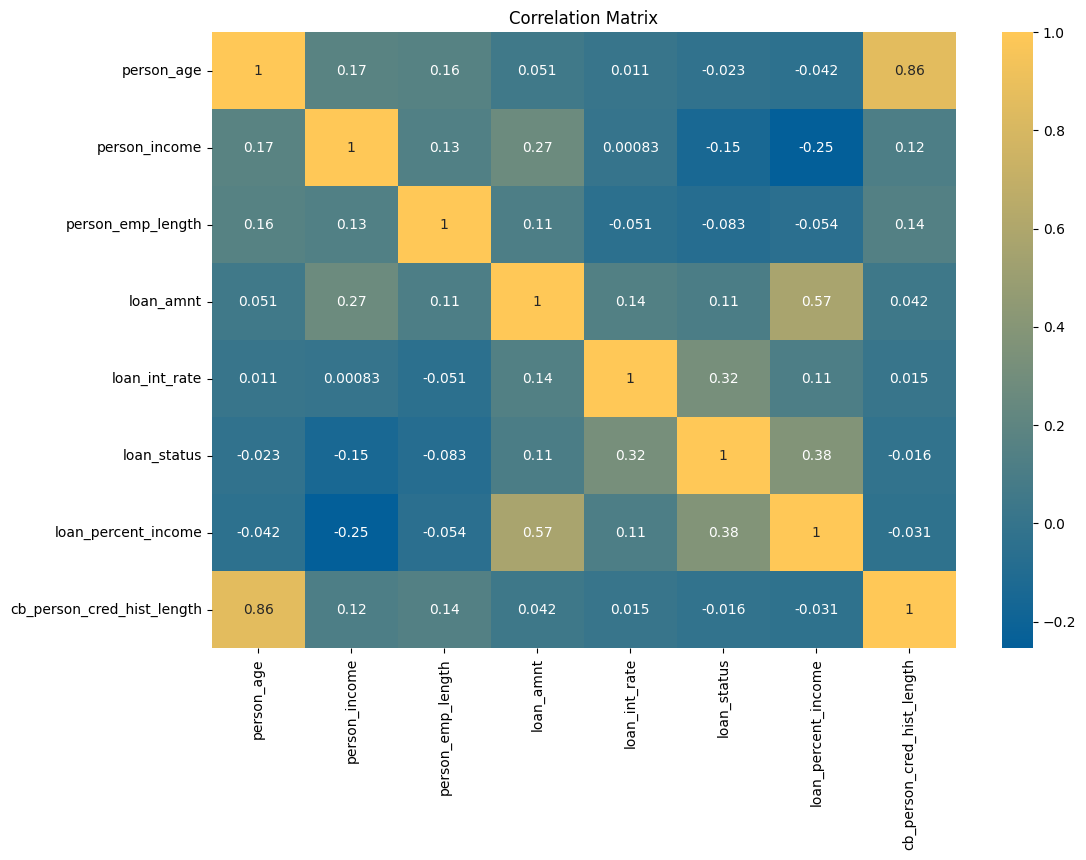

In [21]:
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
cmap_custom = LinearSegmentedColormap.from_list("custom_cmap", ['#035F99', '#FFC857'])
sns.heatmap(correlation_matrix, annot=True, cmap=cmap_custom)
plt.title('Correlation Matrix')
plt.show()

Heatmap menunjukkan hubungan antar variabel, dengan usia (person_age) dan panjang sejarah kredit pensiun (pension_cred_hist_length) memiliki korelasi positif terkuat (0.86), sementara persentase pendapatan untuk pinjaman (loan_percent_income) berkorelasi kuat dengan jumlah pinjaman (loan_amnt) (0.57), dan tingkat bunga pinjaman (loan_int_rate) berkorelasi positif dengan status pinjaman (loan_status) (0.32).

### Boxplot

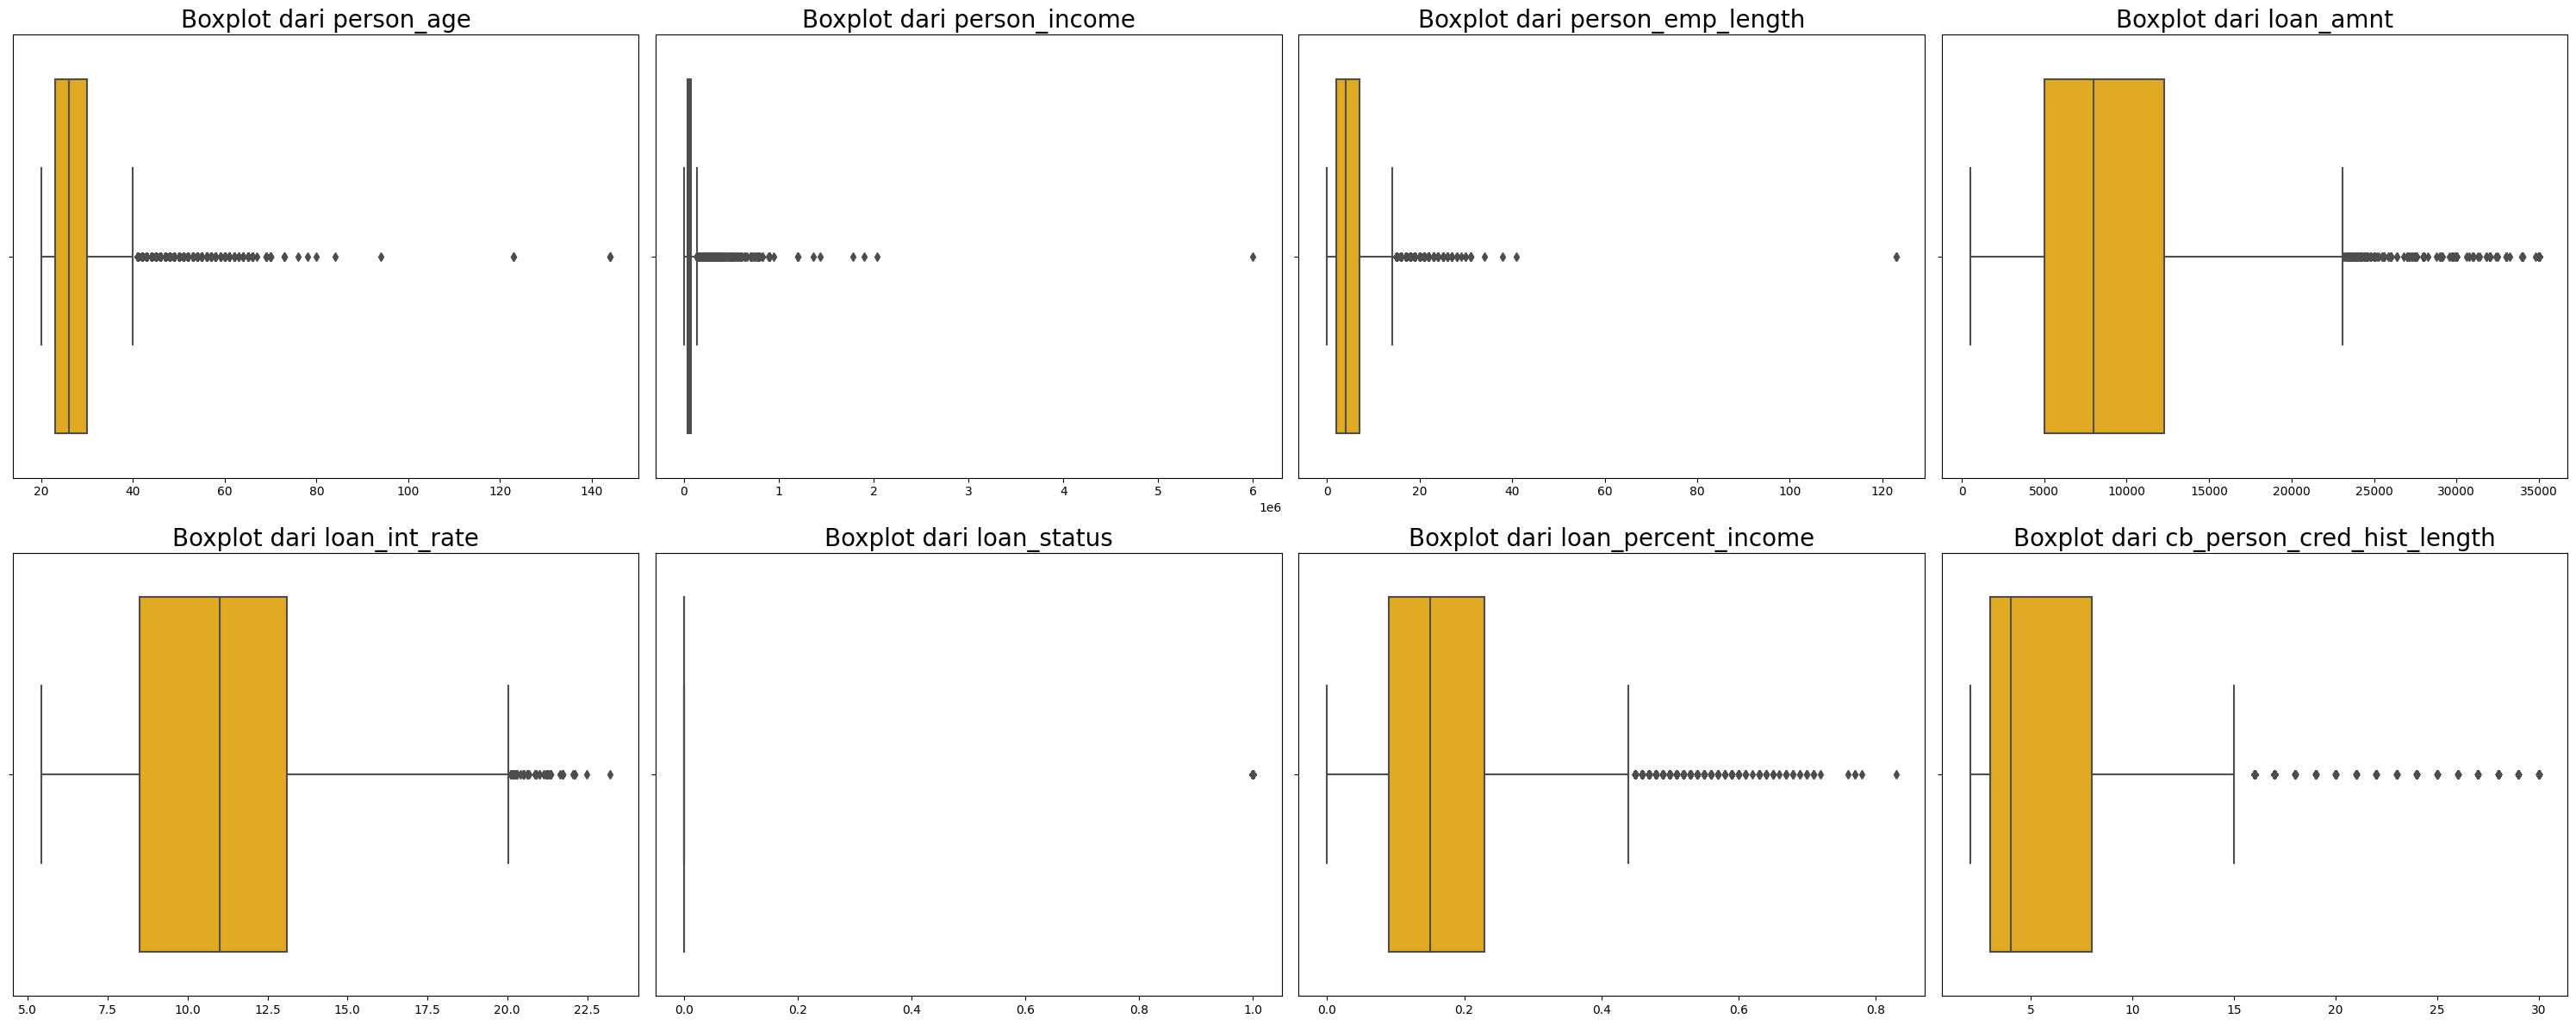

In [22]:
# Hitung jumlah subplot yang dibutuhkan
num_plots = len(numerical_features)

# Tentukan jumlah baris dan kolom untuk subplot
cols = 4  # Jumlah kolom
rows = num_plots // cols  # Hitung jumlah baris
if num_plots % cols != 0:  # Jika ada sisa, tambah satu baris lagi
    rows += 1

# Definisikan ukuran figure dan axes
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(30, 6 * rows))
axes = axes.flatten()  # Ubah array axes menjadi satu dimensi

# Loop melalui fitur numerik dan buat boxplot
for i, col in enumerate(numerical_features):
    if i < num_plots:
        sns.boxplot(x=df[col], ax=axes[i], color='#FFB703')  # Buat boxplot
        axes[i].set_title(f'Boxplot dari {col}', fontsize=20)  # Judul plot
        axes[i].set_xlabel('')  # Hapus label sumbu X
        axes[i].set_ylabel('')  # Hapus label sumbu Y

# Hapus axes yang tidak digunakan jika ada sisa ruang kosong
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

# Sesuaikan tata letak dan tampilkan plot
plt.tight_layout()  # Atur tata letak agar tidak tumpang tindih
plt.show()  # Tampilkan plot


Hampir semua variabel numerik memiliki outlier yang cukup banyak, terutama pada person_age, person_income, person_emp_length, loan_amnt, dan loan_int_rate. Ini menunjukkan adanya individu dengan nilai ekstrem yang jauh dari distribusi utama data.

### Distribusi Histogram

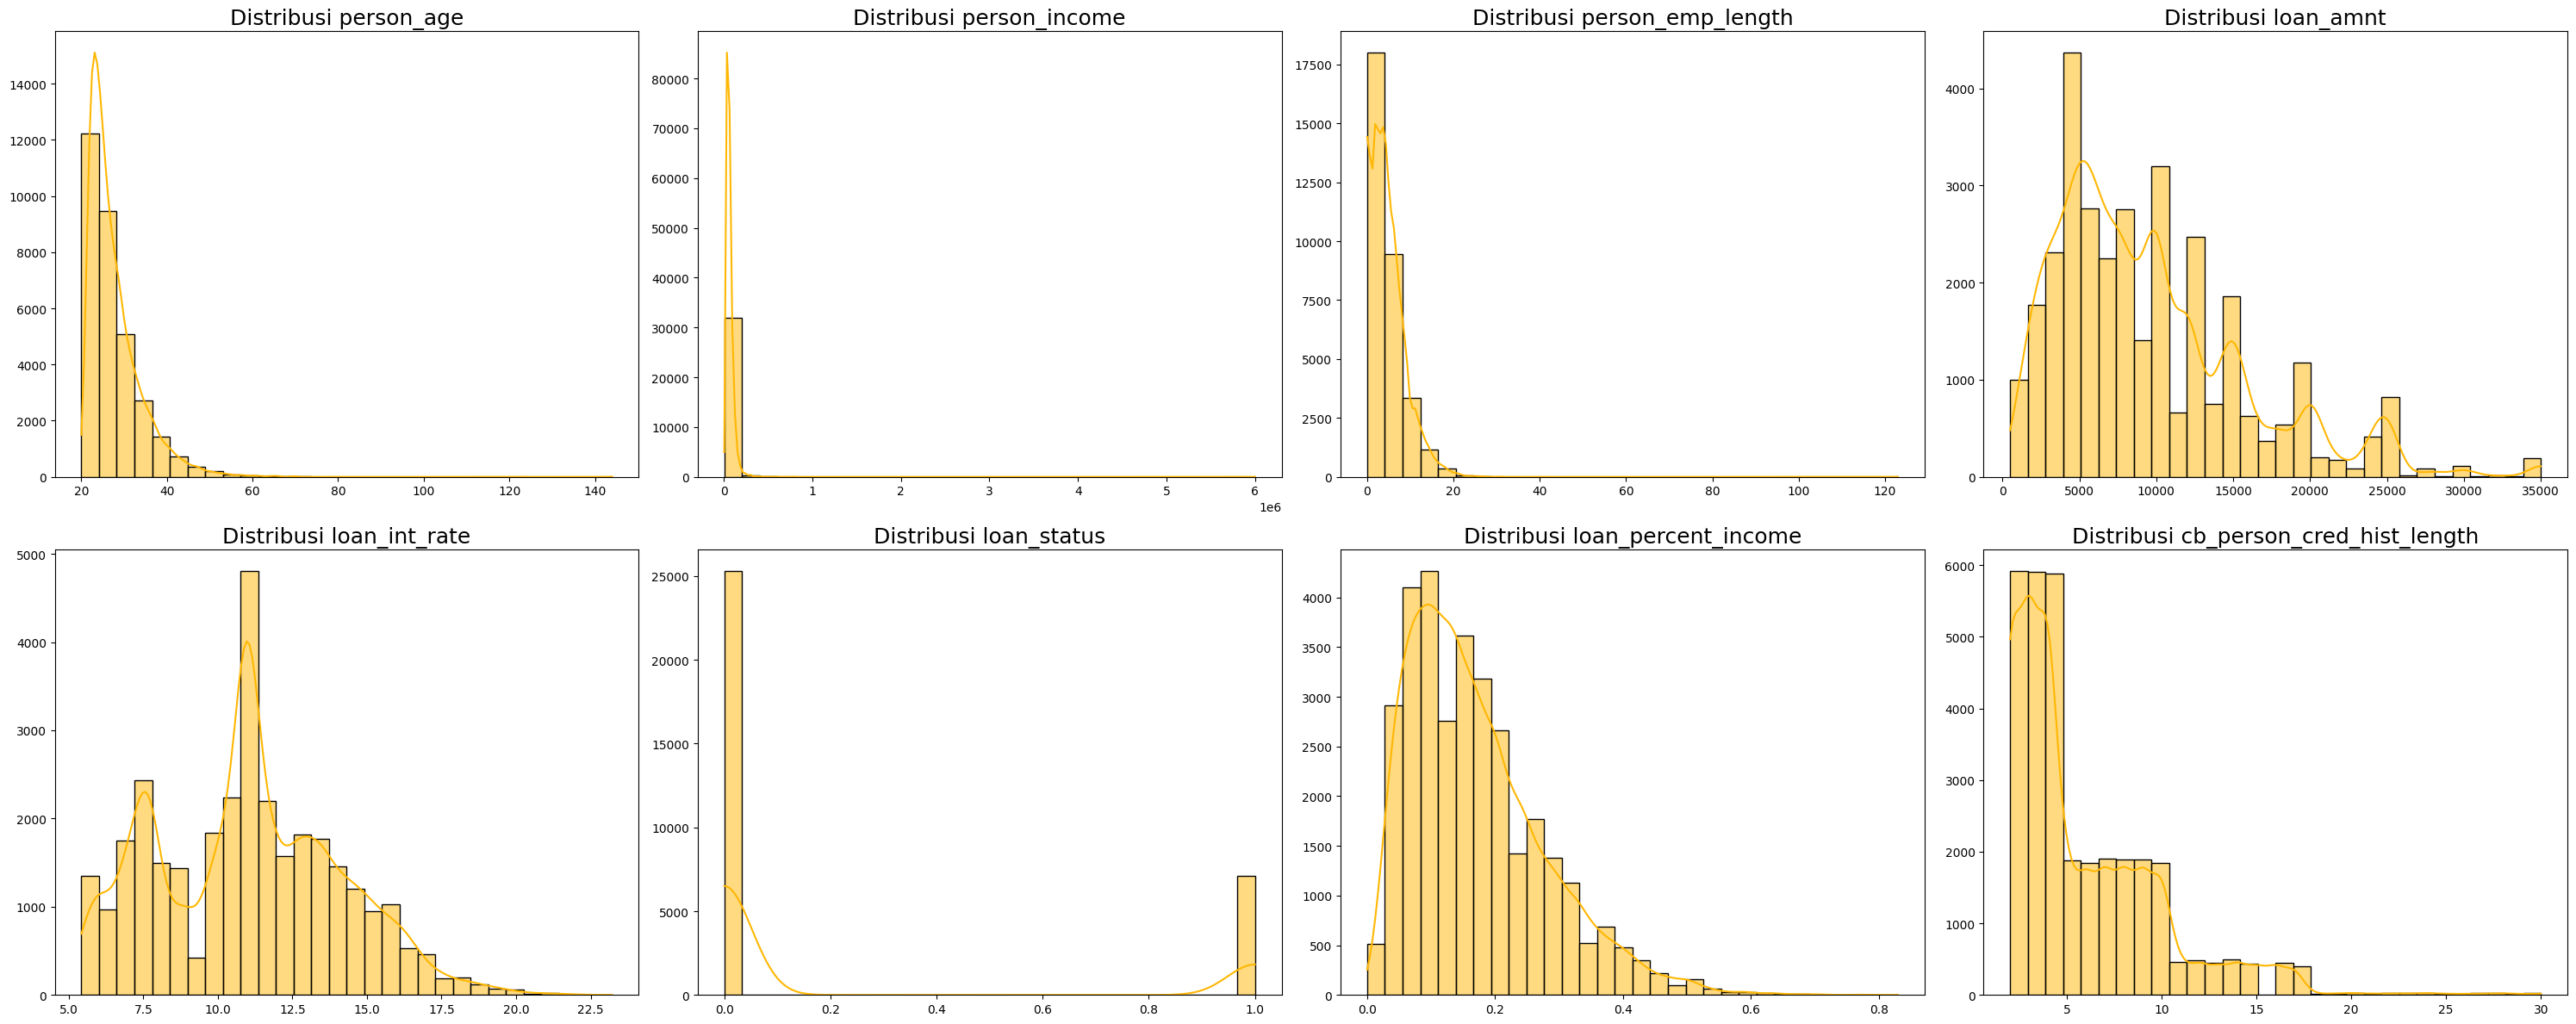

In [23]:
# Tentukan jumlah subplot yang dibutuhkan
num_plots = len(numerical_features)

# Tentukan jumlah baris dan kolom untuk subplot
cols = 4  # Jumlah kolom
rows = num_plots // cols
if num_plots % cols != 0:
    rows += 1

# Definisikan figure dan axes
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(30, 6 * rows))
axes = axes.flatten()  # Ubah array axes menjadi satu dimensi

# Loop melalui fitur numerik dan buat histogram
for i, col in enumerate(numerical_features):
    if i < num_plots:
        sns.histplot(df[col], ax=axes[i], kde=True, bins=30, color='#FFB703')  # Histogram dengan KDE
        axes[i].set_title(f'Distribusi {col}', fontsize=18
                          )  # Judul plot
        axes[i].set_xlabel('')  # Hapus label sumbu X
        axes[i].set_ylabel('')  # Hapus label sumbu Y

# Hapus axes yang tidak digunakan jika ada sisa ruang kosong
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

# Sesuaikan tata letak dan tampilkan plot
plt.tight_layout()  # Atur tata letak agar tidak tumpang tindih
plt.show()  # Tampilkan plot

Distribusi data cenderung skewed ke kanan dengan beberapa outlier, terutama pada variabel person_age, person_income, dan loan_amnt. Loan_int_rate menunjukkan pola bimodal, yang bisa mengindikasikan adanya segmentasi dalam data. Selain itu, mayoritas individu memiliki riwayat kredit pendek, yang bisa menjadi faktor risiko dalam analisis kredit.

### Distribusi Status Pinjaman

In [24]:
print(df['loan_status'].value_counts())


loan_status
0    25327
1     7089
Name: count, dtype: int64


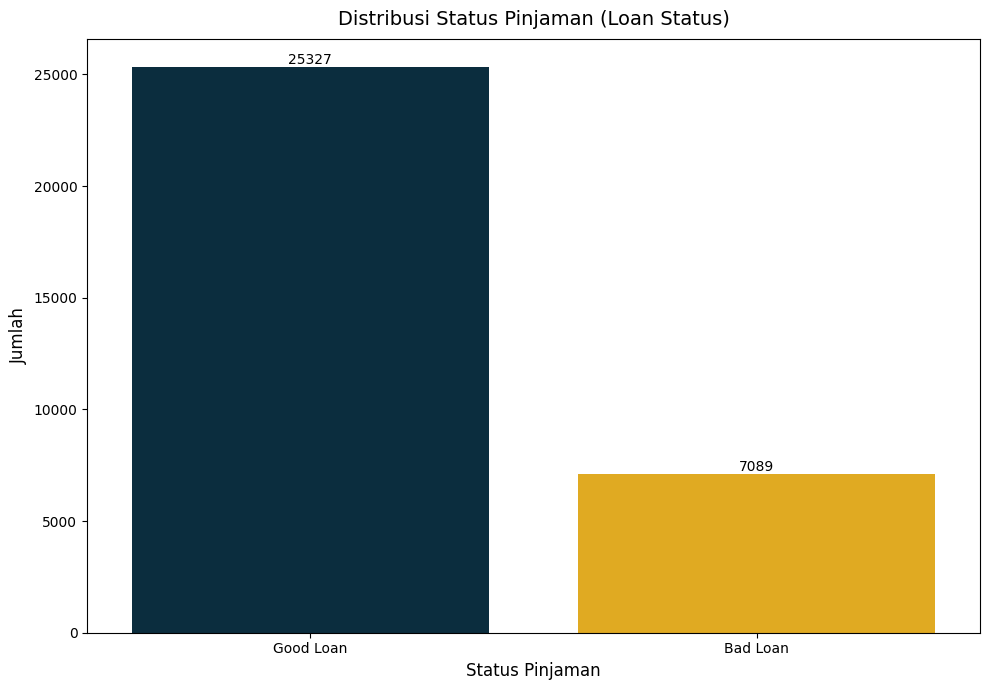

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ubah loan_status dari angka ke kategori
df['loan_status'] = df['loan_status'].map({0: 'Good Loan', 1: 'Bad Loan'})

# Hitung jumlah masing-masing kategori
order = df['loan_status'].value_counts().index

# Membuat figure
plt.figure(figsize=(10, 7))

# Membuat countplot dengan warna yang ditentukan dan legenda disembunyikan
ax = sns.countplot(x='loan_status', data=df,
                    palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}, order=order)

# Menambahkan anotasi pada setiap bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),  # Menggeser anotasi agar tidak terlalu dekat dengan ujung
                textcoords='offset points',
                fontsize=10)

# Mengatur label sumbu x sesuai urutan
ax.set_xticklabels(order)

# Menambahkan elemen tambahan ke dalam plot
plt.title('Distribusi Status Pinjaman (Loan Status)', fontsize=14, pad=10)
plt.xlabel('Status Pinjaman', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Menampilkan plot
plt.tight_layout()
plt.show()


### Distribusi Status Pinjaman Berdasarkan Umur

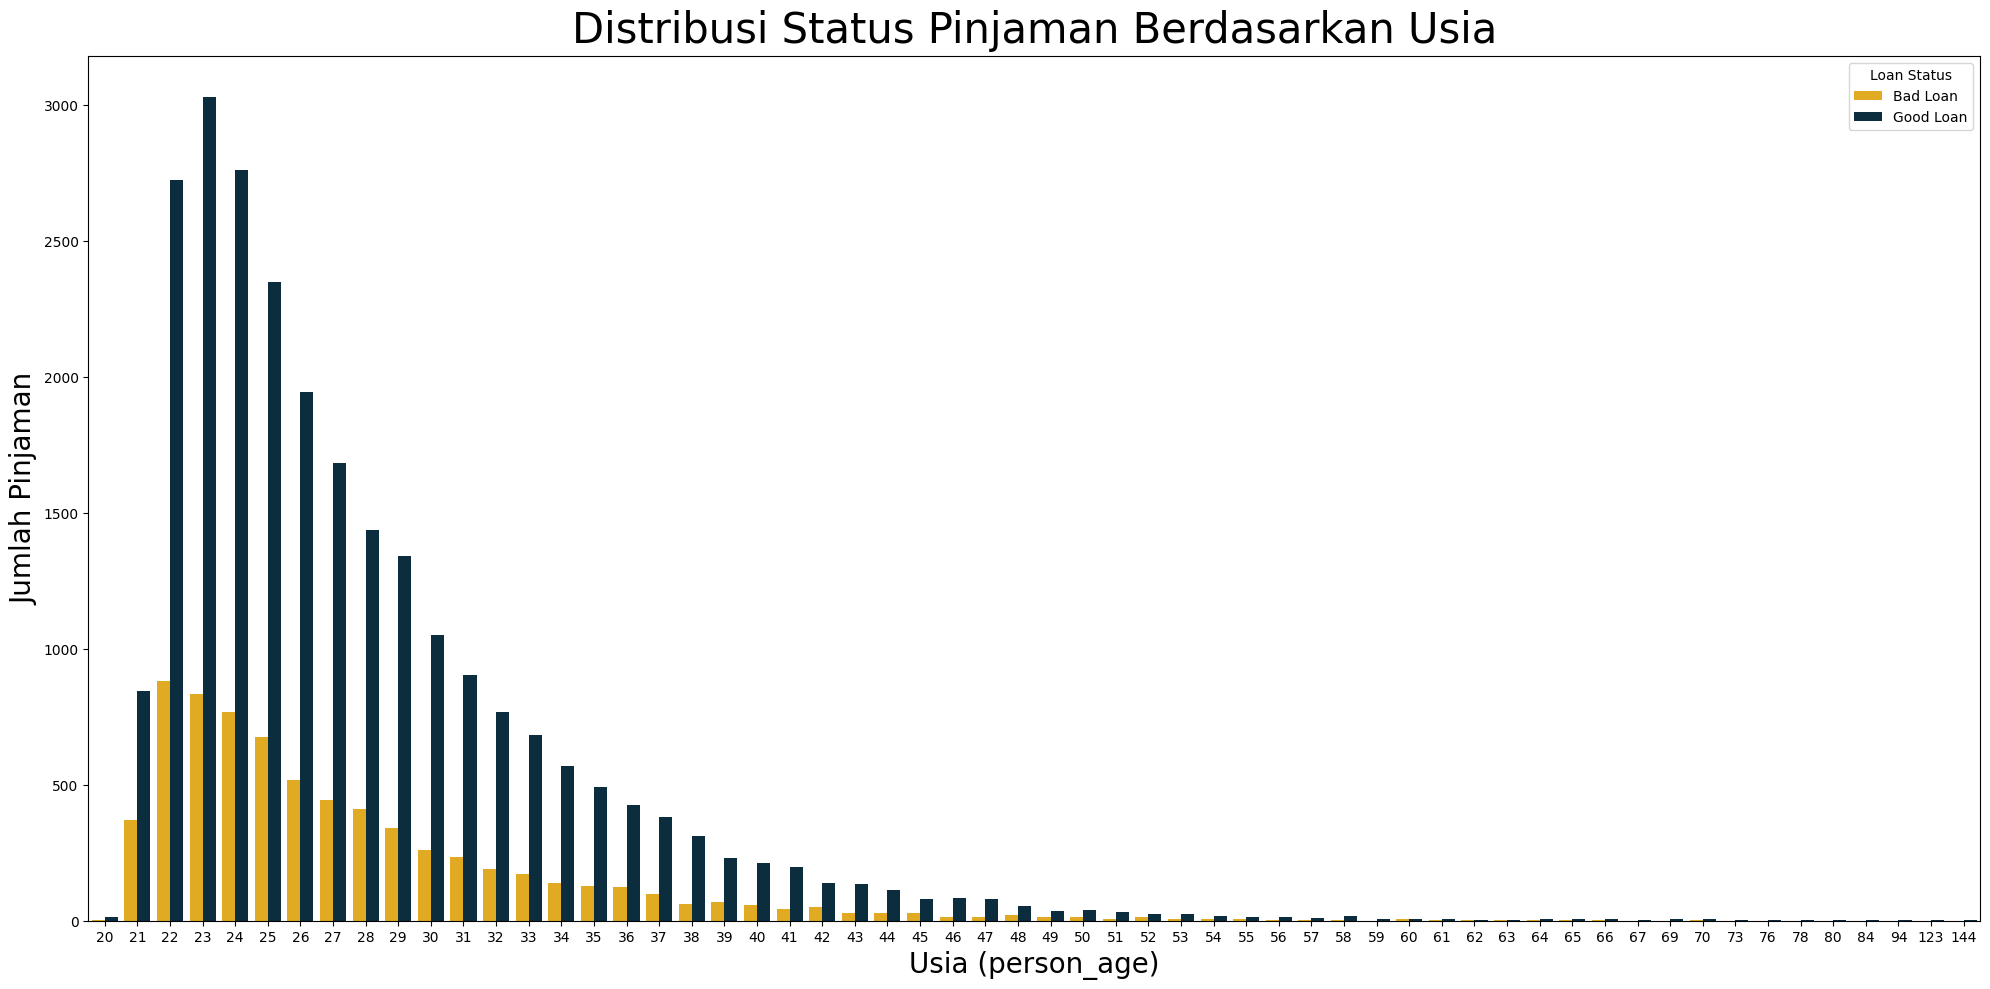

In [26]:
# Ukuran grafik yang lebih besar untuk memudahkan analisis
plt.figure(figsize=[20,10])

# Membuat countplot dengan warna yang spesifik
sns.countplot(x='person_age',
              hue='loan_status',
              data=df,
              palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}  )

# Mengatur label untuk mengganti 0 dan 1 menjadi "Good Loan" dan "Bad Loan"
plt.legend(title='Loan Status')

# Memberikan judul, label sumbu x dan y untuk penyesuaian visualisasi
plt.title('Distribusi Status Pinjaman Berdasarkan Usia', fontsize=30, pad=10)
plt.xlabel('Usia (person_age)', fontsize=20)
plt.ylabel('Jumlah Pinjaman', fontsize=20)

# Memastikan layout tidak berantakan dan elemen tampil dengan rapi
plt.tight_layout()

# Menampilkan plot
plt.show()

Peminjam usia 21-30 tahun memiliki risiko kredit lebih tinggi dengan lebih banyak Bad Loan, sedangkan usia di atas 30 tahun didominasi Good Loan, menunjukkan peningkatan stabilitas finansial seiring bertambahnya usia.

### Perbandingan Status Kepemilikan Rumah dengan Loan Status

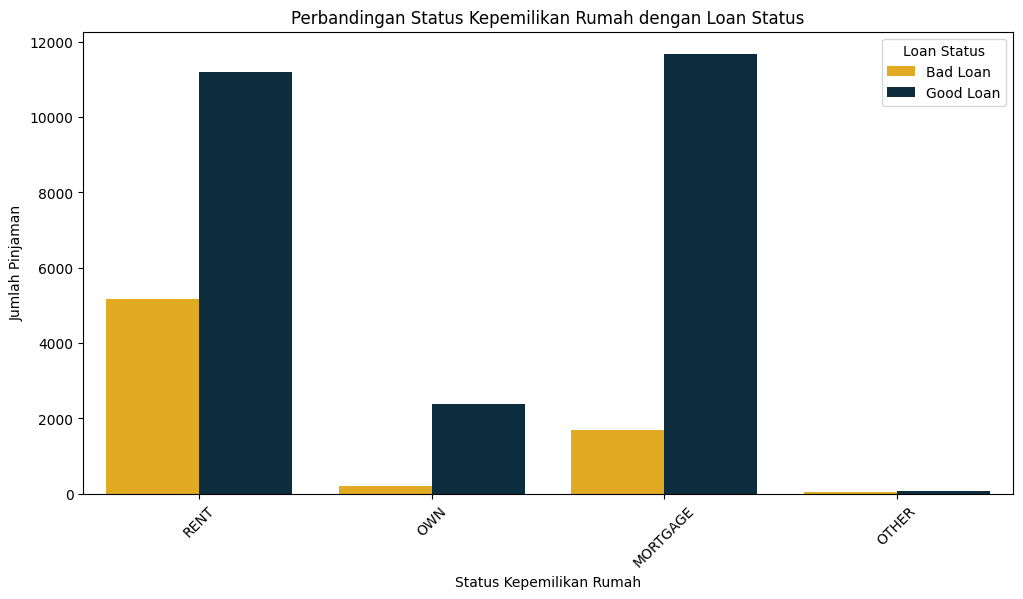

In [27]:
# Membuat bar chart untuk membandingkan person_home_ownership dengan loan_status
plt.figure(figsize=(12, 6))
sns.countplot(
    x='person_home_ownership',
    hue='loan_status',
    data=df,
    palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}
)

# Memberikan detail pada plot
plt.title('Perbandingan Status Kepemilikan Rumah dengan Loan Status')
plt.xlabel('Status Kepemilikan Rumah')
plt.ylabel('Jumlah Pinjaman')
plt.legend(title='Loan Status')

# Menampilkan grafik
plt.xticks(rotation=45)  # Memutar label x agar lebih rapi jika panjang
plt.show()


Peminjam yang menyewa rumah (RENT) memiliki jumlah Bad Loan tertinggi, sedangkan pemilik rumah dengan hipotek (MORTGAGE) lebih banyak memiliki Good Loan, menunjukkan bahwa kepemilikan rumah berkorelasi dengan stabilitas finansial yang lebih baik.

### Perbandingan Loan Grade dengan Loan Status

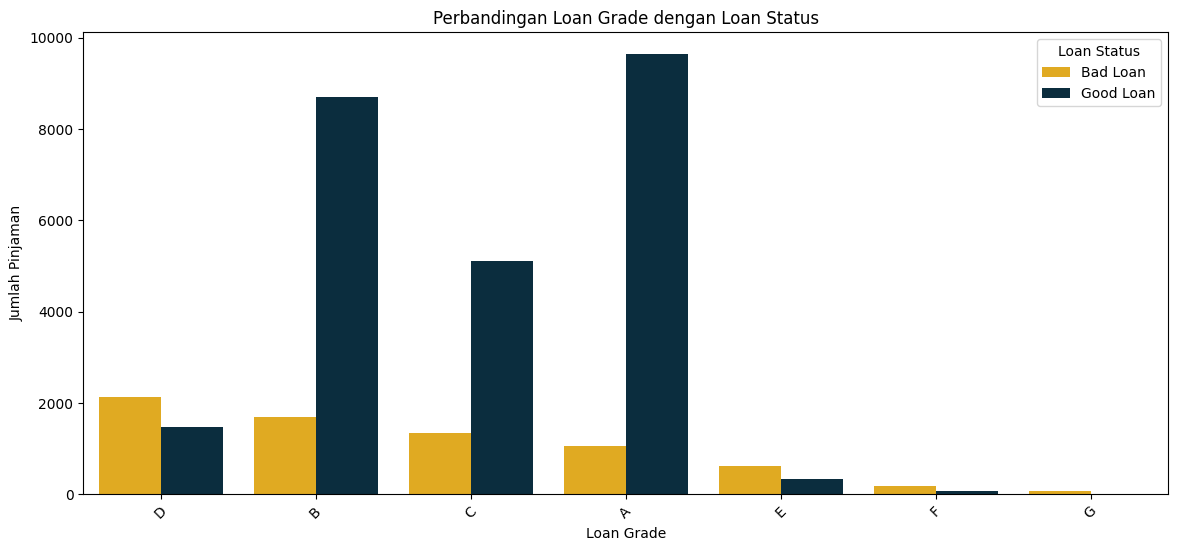

In [28]:
# Membuat bar chart untuk membandingkan loan_grade dengan loan_status
plt.figure(figsize=(14, 6))
sns.countplot(
    x='loan_grade',
    hue='loan_status',
    data=df,
    palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}
)

# Memberikan detail pada plot
plt.title('Perbandingan Loan Grade dengan Loan Status')
plt.xlabel('Loan Grade')
plt.ylabel('Jumlah Pinjaman')
plt.legend(title='Loan Status')

# Memutar sumbu x agar label lebih rapi jika panjang
plt.xticks(rotation=45)

# Menampilkan grafik
plt.show()

### Perbandingan Loan Intent dengan Loan Status

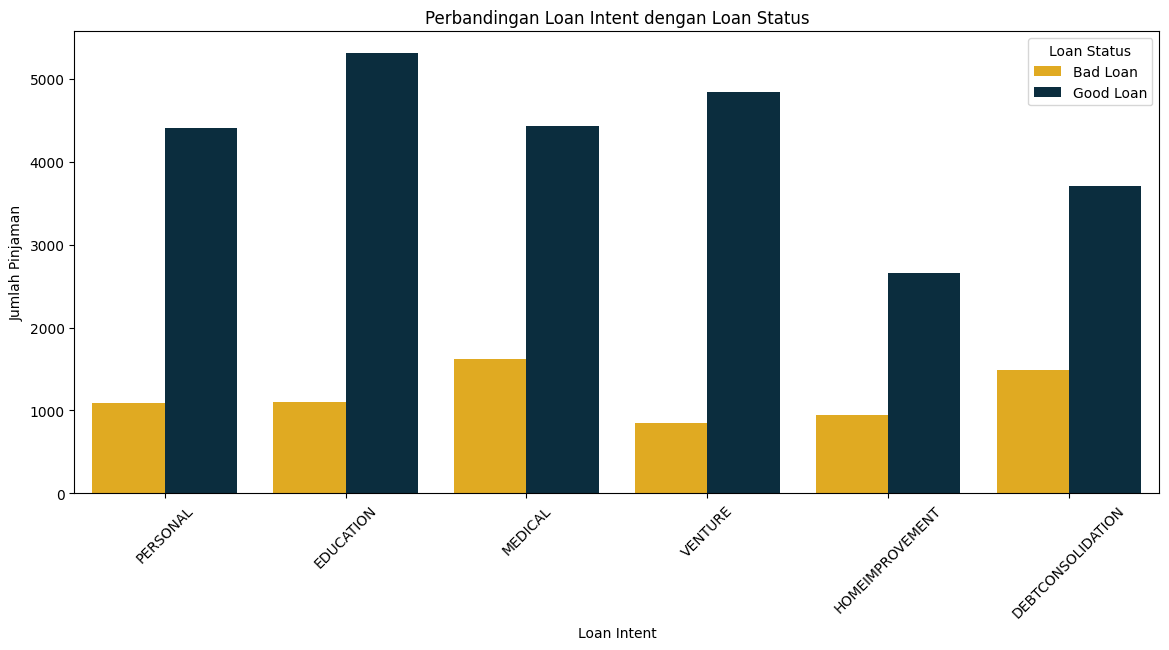

In [29]:
# Membuat bar chart untuk membandingkan loan_intent dengan loan_status
plt.figure(figsize=(14, 6))
sns.countplot(
    x='loan_intent',
    hue='loan_status',
    data=df,
    palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}
)

# Memberikan detail pada plot
plt.title('Perbandingan Loan Intent dengan Loan Status')
plt.xlabel('Loan Intent')
plt.ylabel('Jumlah Pinjaman')
plt.legend(title='Loan Status')

# Memutar sumbu x agar label lebih rapi jika panjang
plt.xticks(rotation=45)

# Menampilkan grafik
plt.show()

Pinjaman dengan tujuan Medical dan Debt Consolidation memiliki proporsi Bad Loan lebih tinggi dibanding tujuan lain, menunjukkan bahwa peminjam dengan kebutuhan medis dan pelunasan utang cenderung memiliki risiko kredit lebih besar.

### Perbandingan Status Gagal Bayar Historis dengan Loan Status

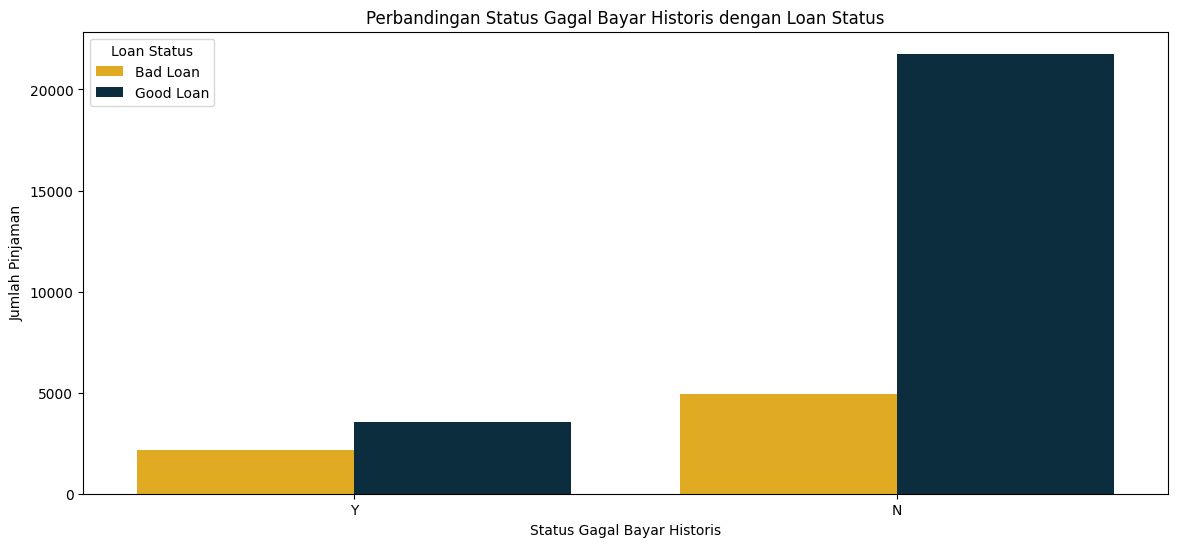

In [30]:
# Membuat bar chart untuk membandingkan cb_person_default_on_file dengan loan_status
plt.figure(figsize=(14, 6))
sns.countplot(
    x='cb_person_default_on_file',
    hue='loan_status',
    data=df,
    palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}
)

# Memberikan detail pada plot
plt.title('Perbandingan Status Gagal Bayar Historis dengan Loan Status')
plt.xlabel('Status Gagal Bayar Historis')
plt.ylabel('Jumlah Pinjaman')
plt.legend(title='Loan Status')

# Memutar sumbu x agar label lebih rapi jika panjang
plt.xticks(rotation=0)

# Menampilkan grafik
plt.show()

Dari data ini, terlihat bahwa peminjam tanpa riwayat gagal bayar memiliki kemungkinan jauh lebih tinggi untuk mendapatkan Good Loan.
Sebaliknya, peminjam dengan riwayat gagal bayar masih memiliki peluang mendapatkan Good Loan, tetapi lebih kecil dibandingkan mereka yang tidak pernah gagal bayar.

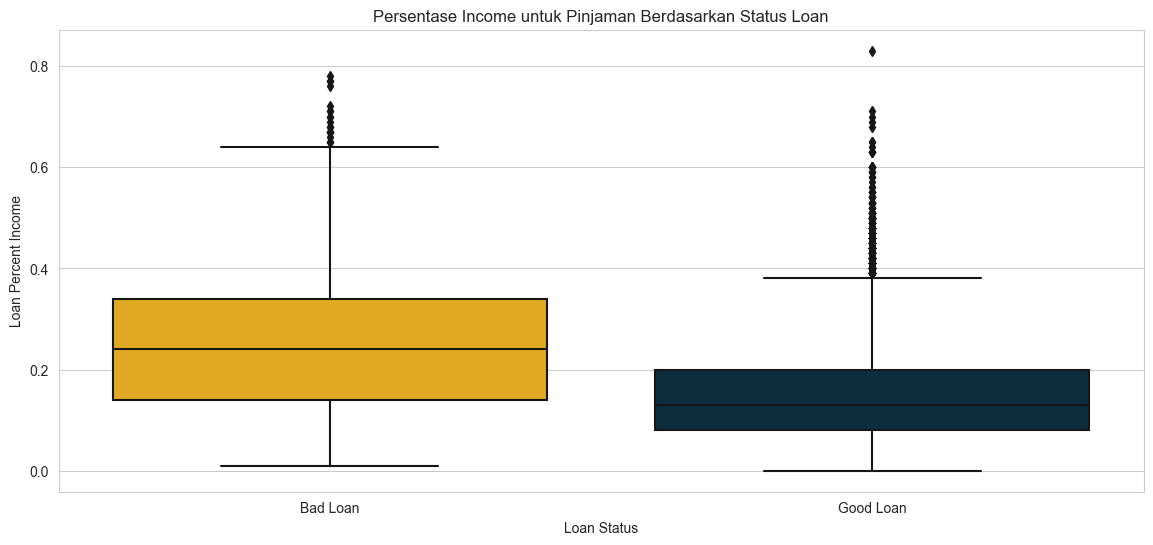

In [31]:
sns.set_style("whitegrid")

# 1. Loan Percent Income vs Loan Status
plt.figure(figsize=(14, 6))
sns.boxplot(
    x='loan_status',
    y='loan_percent_income',
    data=df,
    palette={'Good Loan': '#023047', 'Bad Loan': '#FFB703'}
)
plt.title('Persentase Income untuk Pinjaman Berdasarkan Status Loan')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percent Income')
plt.show()

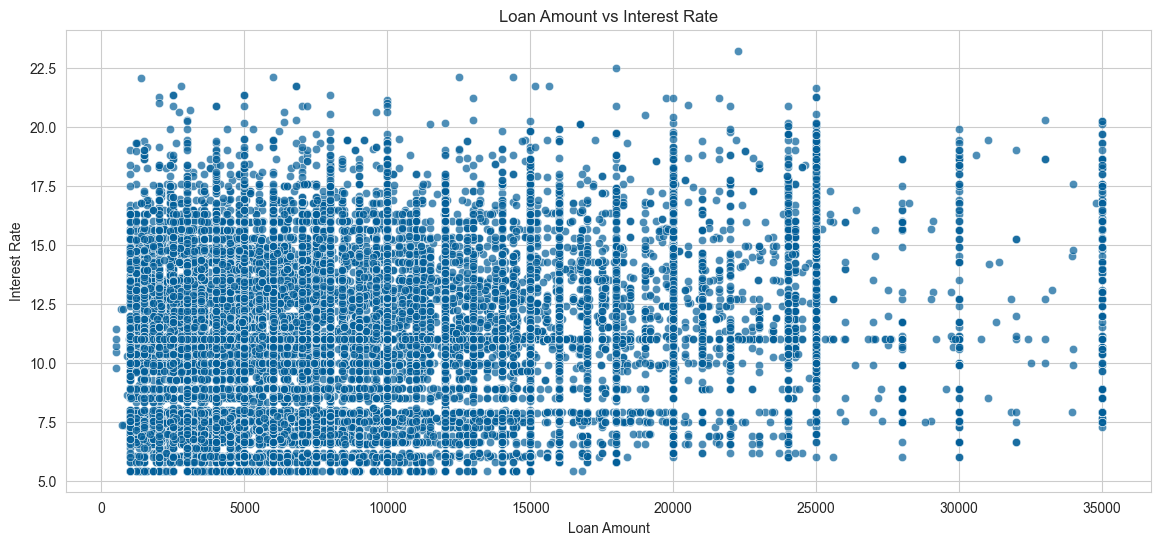

In [32]:
# 3. Loan Amount vs Interest Rate
plt.figure(figsize=(14, 6))
sns.scatterplot(
    x=df['loan_amnt'],
    y=df['loan_int_rate'],
    alpha=0.7,
    color='#035F99'
)
plt.title('Loan Amount vs Interest Rate')
plt.xlabel('Loan Amount')
plt.ylabel('Interest Rate')
plt.show()


Tidak ada korelasi yang jelas antara jumlah pinjaman (Loan Amount) dan suku bunga (Interest Rate). Pinjaman dengan jumlah kecil hingga besar memiliki distribusi suku bunga yang tersebar luas, tetapi ada beberapa pola horizontal yang menunjukkan bahwa suku bunga tertentu lebih umum digunakan. Selain itu, beberapa lonjakan jumlah pinjaman di angka tertentu mengindikasikan adanya batasan standar dalam jumlah pinjaman yang diberikan.

# __WEEK-3 IDENTIFIKASI MASALAH DATASET__
beberapa masalah pada dataset seperti mengisi nilai kosong dan menghapus data duplikat telah dilakukan pada WEEK-1. Jadi disini akan melanjutkan mengidentifikasi maalah pada dataset lebih lanjut seperti menghandling outlier, membuat fitur baru, data binning, data encoding, data scalling dan mengatasi imbalance pada data.

## _Data Preparation_

### Outlier Handling
dimulai dengan memanggil fitur numerik ulang, dikarenakan sebelumnya terdapat satu perubahan nilai numerik ke kategorikal (loan status). Kemudian mendeteksi dan menghapus outlier menggunakan metode IQR untuk meningkatkan akurasi analisis. Dari boxplot, variabel person_age memiliki banyak outlier dengan nilai tidak realistis (>100 tahun), sehingga perlu ditangani agar tidak mempengaruhi model.

In [33]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

In [34]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in numerical_features:
    data_outlier = remove_outliers(df, col)

In [35]:
print("Total row before remove outlier:")
print(df.shape)
print("\nTotal row after remove outlier:")
print(data_outlier.shape)

Total row before remove outlier:
(32416, 12)

Total row after remove outlier:
(31277, 12)


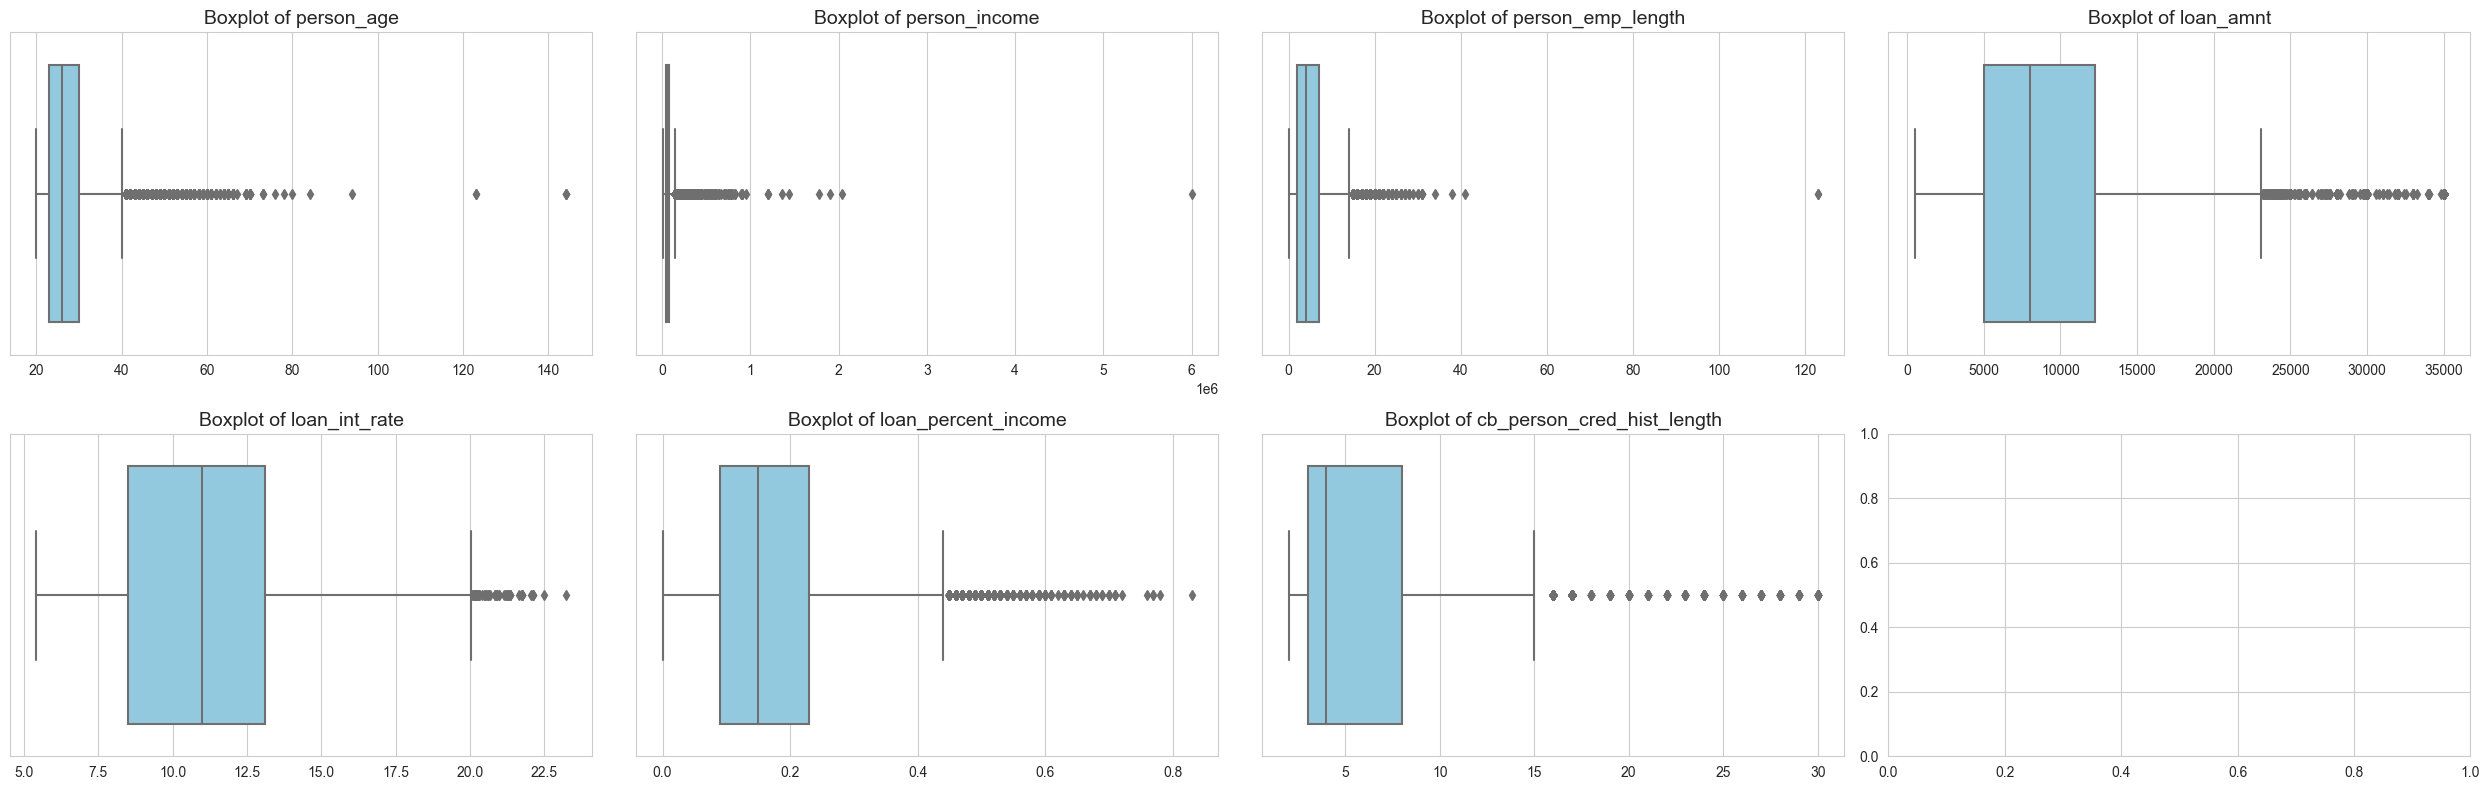

In [36]:
# Determine number of rows and columns for subplots
numerical_features = data_outlier.select_dtypes(include=['int64', 'float64']).columns

cols = 4
rows = num_plots // cols
if num_plots % cols != 0:
    rows += 1

# Define figure and axes
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(25, 4 * rows))
axes = axes.flatten()

# Loop through numerical features and create boxplots
for i, col in enumerate(numerical_features):
    if i < num_plots:
        sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Boxplot of {col}', fontsize=14)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

# Remove any unused axes
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout and show plot
plt.tight_layout()
plt.show()

### Person_Age OutlierHandling (>100)

In [37]:
data_outlier['person_age'].max()

144

In [38]:
data_outlier = data_outlier[data_outlier['person_age'] < 100]

In [39]:
data_outlier['person_age'].max()

50

### Feature Engineering
Membuat fitur baru agar analisis lebih akurat. Loan-to-income ratio menunjukkan seberapa besar pinjaman dibanding pendapatan, loan-to-employment length ratio melihat hubungan lama bekerja dengan jumlah pinjaman, dan interest rate-to-loan amount ratio menggambarkan keterkaitan tingkat bunga dengan pinjaman.

In [40]:
df2 = data_outlier.copy()

In [41]:
# Create loan-to-income ratio
df2['loan_to_income_ratio'] = df2['loan_amnt'] / df2['person_income']

# Create loan-to-employment length ratio
df2['loan_to_emp_length_ratio'] =  df2['person_emp_length']/ df2['loan_amnt']

# Create interest rate-to-loan amount ratio
df2['int_rate_to_loan_amt_ratio'] = df2['loan_int_rate'] / df2['loan_amnt']

In [42]:
df2

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,Bad Loan,0.59,Y,3,0.593220,0.003514,0.000458
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,Good Loan,0.10,N,2,0.104167,0.005000,0.011140
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,Bad Loan,0.57,N,3,0.572917,0.000182,0.002340
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,Bad Loan,0.53,N,2,0.534351,0.000114,0.000435
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,Bad Loan,0.55,Y,4,0.643382,0.000229,0.000408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32290,37,90000,MORTGAGE,11.0,DEBTCONSOLIDATION,A,4000,6.62,Good Loan,0.04,N,15,0.044444,0.002750,0.001655
32292,38,200000,MORTGAGE,0.0,DEBTCONSOLIDATION,A,3000,7.68,Good Loan,0.01,N,12,0.015000,0.000000,0.002560
32293,38,110000,MORTGAGE,5.0,MEDICAL,B,16000,11.99,Good Loan,0.15,N,13,0.145455,0.000313,0.000749
32294,36,92000,MORTGAGE,18.0,DEBTCONSOLIDATION,A,4000,7.29,Good Loan,0.04,N,13,0.043478,0.004500,0.001822


## _Data Tranformation_

### Data Binning
Mengelompokkan pendapatan dan jumlah pinjaman ke dalam kategori yang lebih mudah dianalisis, seperti low, middle, high untuk pendapatan dan small, medium, large untuk pinjaman agar data menjadi lebih terstruktur, membantu model memahami pola dengan lebih baik, serta mengurangi noise dari variasi angka yang terlalu besar.

#### **Kolom Income Group**

In [43]:
df2['income_group'] = pd.cut(df2['person_income'],
                              bins=[0, 25000, 50000, 75000, 100000, float('inf')],
                              labels=['low', 'low-middle', 'middle', 'high-middle', 'high'])

In [44]:
df2.drop('person_income', axis=1, inplace=True)

In [45]:
df2['income_group'].value_counts()

income_group
low-middle     11181
middle          9268
high-middle     4457
high            3994
low             2373
Name: count, dtype: int64

#### **Kolom Loan Amount**

In [46]:
df2['loan_amount_group'] = pd.cut(df2['loan_amnt'],
                                   bins=[0, 5000, 10000, 15000, float('inf')],
                                   labels=['small', 'medium', 'large', 'very large'])

In [47]:
df2.drop('loan_amnt', axis=1, inplace=True)

In [48]:
df2['loan_amount_group'].value_counts()

loan_amount_group
medium        11558
small          9115
large          5888
very large     4712
Name: count, dtype: int64

### Data Encoding
Mengubah data kategori menjadi format numerik agar bisa diproses oleh model. One Hot Encoding digunakan untuk kategori tanpa urutan, seperti home ownership, sedangkan Label Encoding cocok untuk kategori dengan urutan atau sedikit nilai unik, seperti loan grade atau loan status.

One Hot Encoding

In [49]:
df2

,person_age,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,income_group,loan_amount_group
0,22,RENT,123.0,PERSONAL,D,16.02,Bad Loan,0.59,Y,3,0.593220,0.003514,0.000458,middle,very large
1,21,OWN,5.0,EDUCATION,B,11.14,Good Loan,0.10,N,2,0.104167,0.005000,0.011140,low,small
2,25,MORTGAGE,1.0,MEDICAL,C,12.87,Bad Loan,0.57,N,3,0.572917,0.000182,0.002340,low,medium
3,23,RENT,4.0,MEDICAL,C,15.23,Bad Loan,0.53,N,2,0.534351,0.000114,0.000435,middle,very large
4,24,RENT,8.0,MEDICAL,C,14.27,Bad Loan,0.55,Y,4,0.643382,0.000229,0.000408,middle,very large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32290,37,MORTGAGE,11.0,DEBTCONSOLIDATION,A,6.62,Good Loan,0.04,N,15,0.044444,0.002750,0.001655,high-middle,small
32292,38,MORTGAGE,0.0,DEBTCONSOLIDATION,A,7.68,Good Loan,0.01,N,12,0.015000,0.000000,0.002560,high,small
32293,38,MORTGAGE,5.0,MEDICAL,B,11.99,Good Loan,0.15,N,13,0.145455,0.000313,0.000749,high,very large
32294,36,MORTGAGE,18.0,DEBTCONSOLIDATION,A,7.29,Good Loan,0.04,N,13,0.043478,0.004500,0.001822,high-middle,small


In [50]:
from sklearn.preprocessing import OneHotEncoder


# Membuat fungsi untuk melakukan one-hot encoding
def one_hot_encoding(df2, columns):
    encoder = OneHotEncoder(sparse_output=False)

    for col in columns:
        # Fit dan transform untuk setiap fitur
        encoded_data = encoder.fit_transform(df2[[col]])  # Hasilnya adalah array 2D

        # Ambil nama fitur yang benar untuk setiap kategori
        encoded_columns = encoder.get_feature_names_out([col])  # Nama untuk setiap fitur

        # Membuat DataFrame baru dengan hasil encoding
        encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns, index=df2.index)

        # Gabungkan hasil encoding dengan data
        df2 = pd.concat([df2.drop(columns=[col]), encoded_df], axis=1)

    return df2


# Contoh penggunaan untuk mengencode kolom
columns_to_encode = ['person_home_ownership', 'loan_intent', 'income_group', 'loan_amount_group']

# Lakukan one hot encoding pada semua kolom ini
df2 = one_hot_encoding(df2, columns_to_encode)

In [51]:
print(df2.columns)

Index(['person_age', 'person_emp_length', 'loan_grade', 'loan_int_rate',
       'loan_status', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_to_income_ratio',
       'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'income_group_high',
       'income_group_high-middle', 'income_group_low',
       'income_group_low-middle', 'income_group_middle',
       'loan_amount_group_large', 'loan_amount_group_medium',
       'loan_amount_group_small', 'loan_amount_group_very large'],
      dtype='object')


Label Encoder

In [52]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd


# Membuat fungsi untuk melakukan label encoding
def label_encoding(df2, columns):
    encoder = LabelEncoder()

    for col in columns:
        df2[col] = encoder.fit_transform(df2[col])

    return df2

label_encoder = LabelEncoder()

# Konversi loan_status menjadi numerik
df2['loan_status'] = label_encoder.fit_transform(df2['loan_status'])

# Balik nilai encoding: good loan (0) -> (1-0=1), bad loan (1) -> (1-1=0)
df2['loan_status'] = 1 - df2['loan_status']

# Fitur yang akan dikodekan
columns_to_encode = ['loan_grade', 'cb_person_default_on_file']

# Lakukan label encoding pada semua kolom ini
df2 = label_encoding(df2, columns_to_encode)

In [53]:
print(df2['loan_grade'].unique())
print(df2['loan_status'].unique())
print(df2['cb_person_default_on_file'].unique())

[3 1 2 0 4 5 6]
[1 0]
[1 0]


In [54]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31273 entries, 0 to 32295
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      31273 non-null  int64  
 1   person_emp_length               31273 non-null  float64
 2   loan_grade                      31273 non-null  int32  
 3   loan_int_rate                   31273 non-null  float64
 4   loan_status                     31273 non-null  int32  
 5   loan_percent_income             31273 non-null  float64
 6   cb_person_default_on_file       31273 non-null  int32  
 7   cb_person_cred_hist_length      31273 non-null  int64  
 8   loan_to_income_ratio            31273 non-null  float64
 9   loan_to_emp_length_ratio        31273 non-null  float64
 10  int_rate_to_loan_amt_ratio      31273 non-null  float64
 11  person_home_ownership_MORTGAGE  31273 non-null  float64
 12  person_home_ownership_OTHER     31273

### Data Scaling
Agar fitur memiliki skala yang sama, terutama saat data punya rentang nilai yang jauh berbeda.

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_to_scale = df2.drop('loan_status', axis=1)

ScaledData = scaler.fit_transform(features_to_scale)

ScaledData = pd.DataFrame(ScaledData, columns=features_to_scale.columns, index=df2.index)

ScaledData['loan_status'] = df2['loan_status']

In [56]:
ScaledData

,person_age,person_emp_length,loan_grade,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,...,income_group_high,income_group_high-middle,income_group_low,income_group_low-middle,income_group_middle,loan_amount_group_large,loan_amount_group_medium,loan_amount_group_small,loan_amount_group_very large,loan_status
0,-0.990782,29.591787,1.526522,1.624010,3.927966,2.157818,-0.721149,3.945086,2.615290,-0.762003,...,-0.382640,-0.407685,-0.286550,-0.745983,1.540876,-0.48161,-0.765672,-0.641377,2.374212,1
1,-1.184248,0.067685,-0.187530,0.041695,-0.660138,-0.463431,-1.027198,-0.622866,4.028428,4.955987,...,-0.382640,-0.407685,3.489796,-0.745983,-0.648982,-0.48161,-0.765672,1.559147,-0.421192,0
2,-0.410384,-0.933132,0.669496,0.602639,3.740696,-0.463431,-0.721149,3.755442,-0.554389,0.245543,...,-0.382640,-0.407685,3.489796,-0.745983,-0.648982,-0.48161,1.306042,-0.641377,-0.421192,1
3,-0.797316,-0.182519,0.669496,1.367856,3.366157,-0.463431,-1.027198,3.395225,-0.618622,-0.774085,...,-0.382640,-0.407685,-0.286550,-0.745983,1.540876,-0.48161,-0.765672,-0.641377,2.374212,1
4,-0.603850,0.818298,0.669496,1.056581,3.553427,2.157818,-0.415099,4.413619,-0.509919,-0.788767,...,-0.382640,-0.407685,-0.286550,-0.745983,1.540876,-0.48161,-0.765672,-0.641377,2.374212,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32290,1.911206,1.568911,-1.044556,-1.423891,-1.221947,-0.463431,2.951446,-1.180694,1.888339,-0.121122,...,-0.382640,2.452876,-0.286550,-0.745983,-0.648982,-0.48161,-0.765672,1.559147,-0.421192,0
32292,2.104672,-1.183336,-1.044556,-1.080192,-1.502851,-0.463431,2.033297,-1.455717,-0.727325,0.363304,...,2.613426,-0.407685,-0.286550,-0.745983,-0.648982,-0.48161,-0.765672,1.559147,-0.421192,0
32293,2.104672,0.067685,-0.187530,0.317303,-0.191964,-0.463431,2.339347,-0.237221,-0.430090,-0.605883,...,2.613426,-0.407685,-0.286550,-0.745983,-0.648982,-0.48161,-0.765672,-0.641377,2.374212,0
32294,1.717741,3.320341,-1.044556,-1.206647,-1.221947,-0.463431,2.339347,-1.189719,3.552853,-0.031463,...,-0.382640,2.452876,-0.286550,-0.745983,-0.648982,-0.48161,-0.765672,1.559147,-0.421192,0


### Handling Imbalance Target Data
Loan status tidak seimbang (lebih banyak good loan(0) dari pada bad loan(1), Model akan cenderung bias ke kelas mayoritas. SMOTE ini untuk menambah data sintetis di kelas minoritas agar jumlahnya seimbang.

In [57]:
print("Distribusi data dari variabel Target sebelum di SMOTE:\n", ScaledData['loan_status'].value_counts())

Distribusi data dari variabel Target sebelum di SMOTE:
 loan_status
0    24431
1     6842
Name: count, dtype: int64


In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
columns = ScaledData.columns
X_resampled, y_resampled = smote.fit_resample(ScaledData.drop(columns=['loan_status']), ScaledData['loan_status'])

In [59]:
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=columns[:-1]), pd.DataFrame(y_resampled, columns=['loan_status'])], axis=1)

In [60]:
print("Distribusi data dari variabel Target setelah di SMOTE:\n", df_balanced['loan_status'].value_counts())

Distribusi data dari variabel Target setelah di SMOTE:
 loan_status
1    24431
0    24431
Name: count, dtype: int64


# __WEEK-4 DAN 5 PEMILIHAN MODEL-MENGIDENTIFIKASI MODEL__

## __ARSITEKTUR XGBOOST__

Dalam pengerjaan proyek ini yaitu analisis resiko kredit, agar prediksi apakah peminjam akan memenuhi kewajiban pinjamannya atau tidak maka dibutuhkan untuk memilih algoritma pembelajaran mesin yang tepat. Disini saya memilih __XGBoost (Extreme Gradient Boosting)__ karena algoritmanya yang menawarkan kinerja prediktif yang unggul dengan efisiensi komputasi tinggi. Berikut ini penjelasan dari arsitektur algoritma __XGBoost (Extreme Gradient Boosting)__ yang telah saya buat :

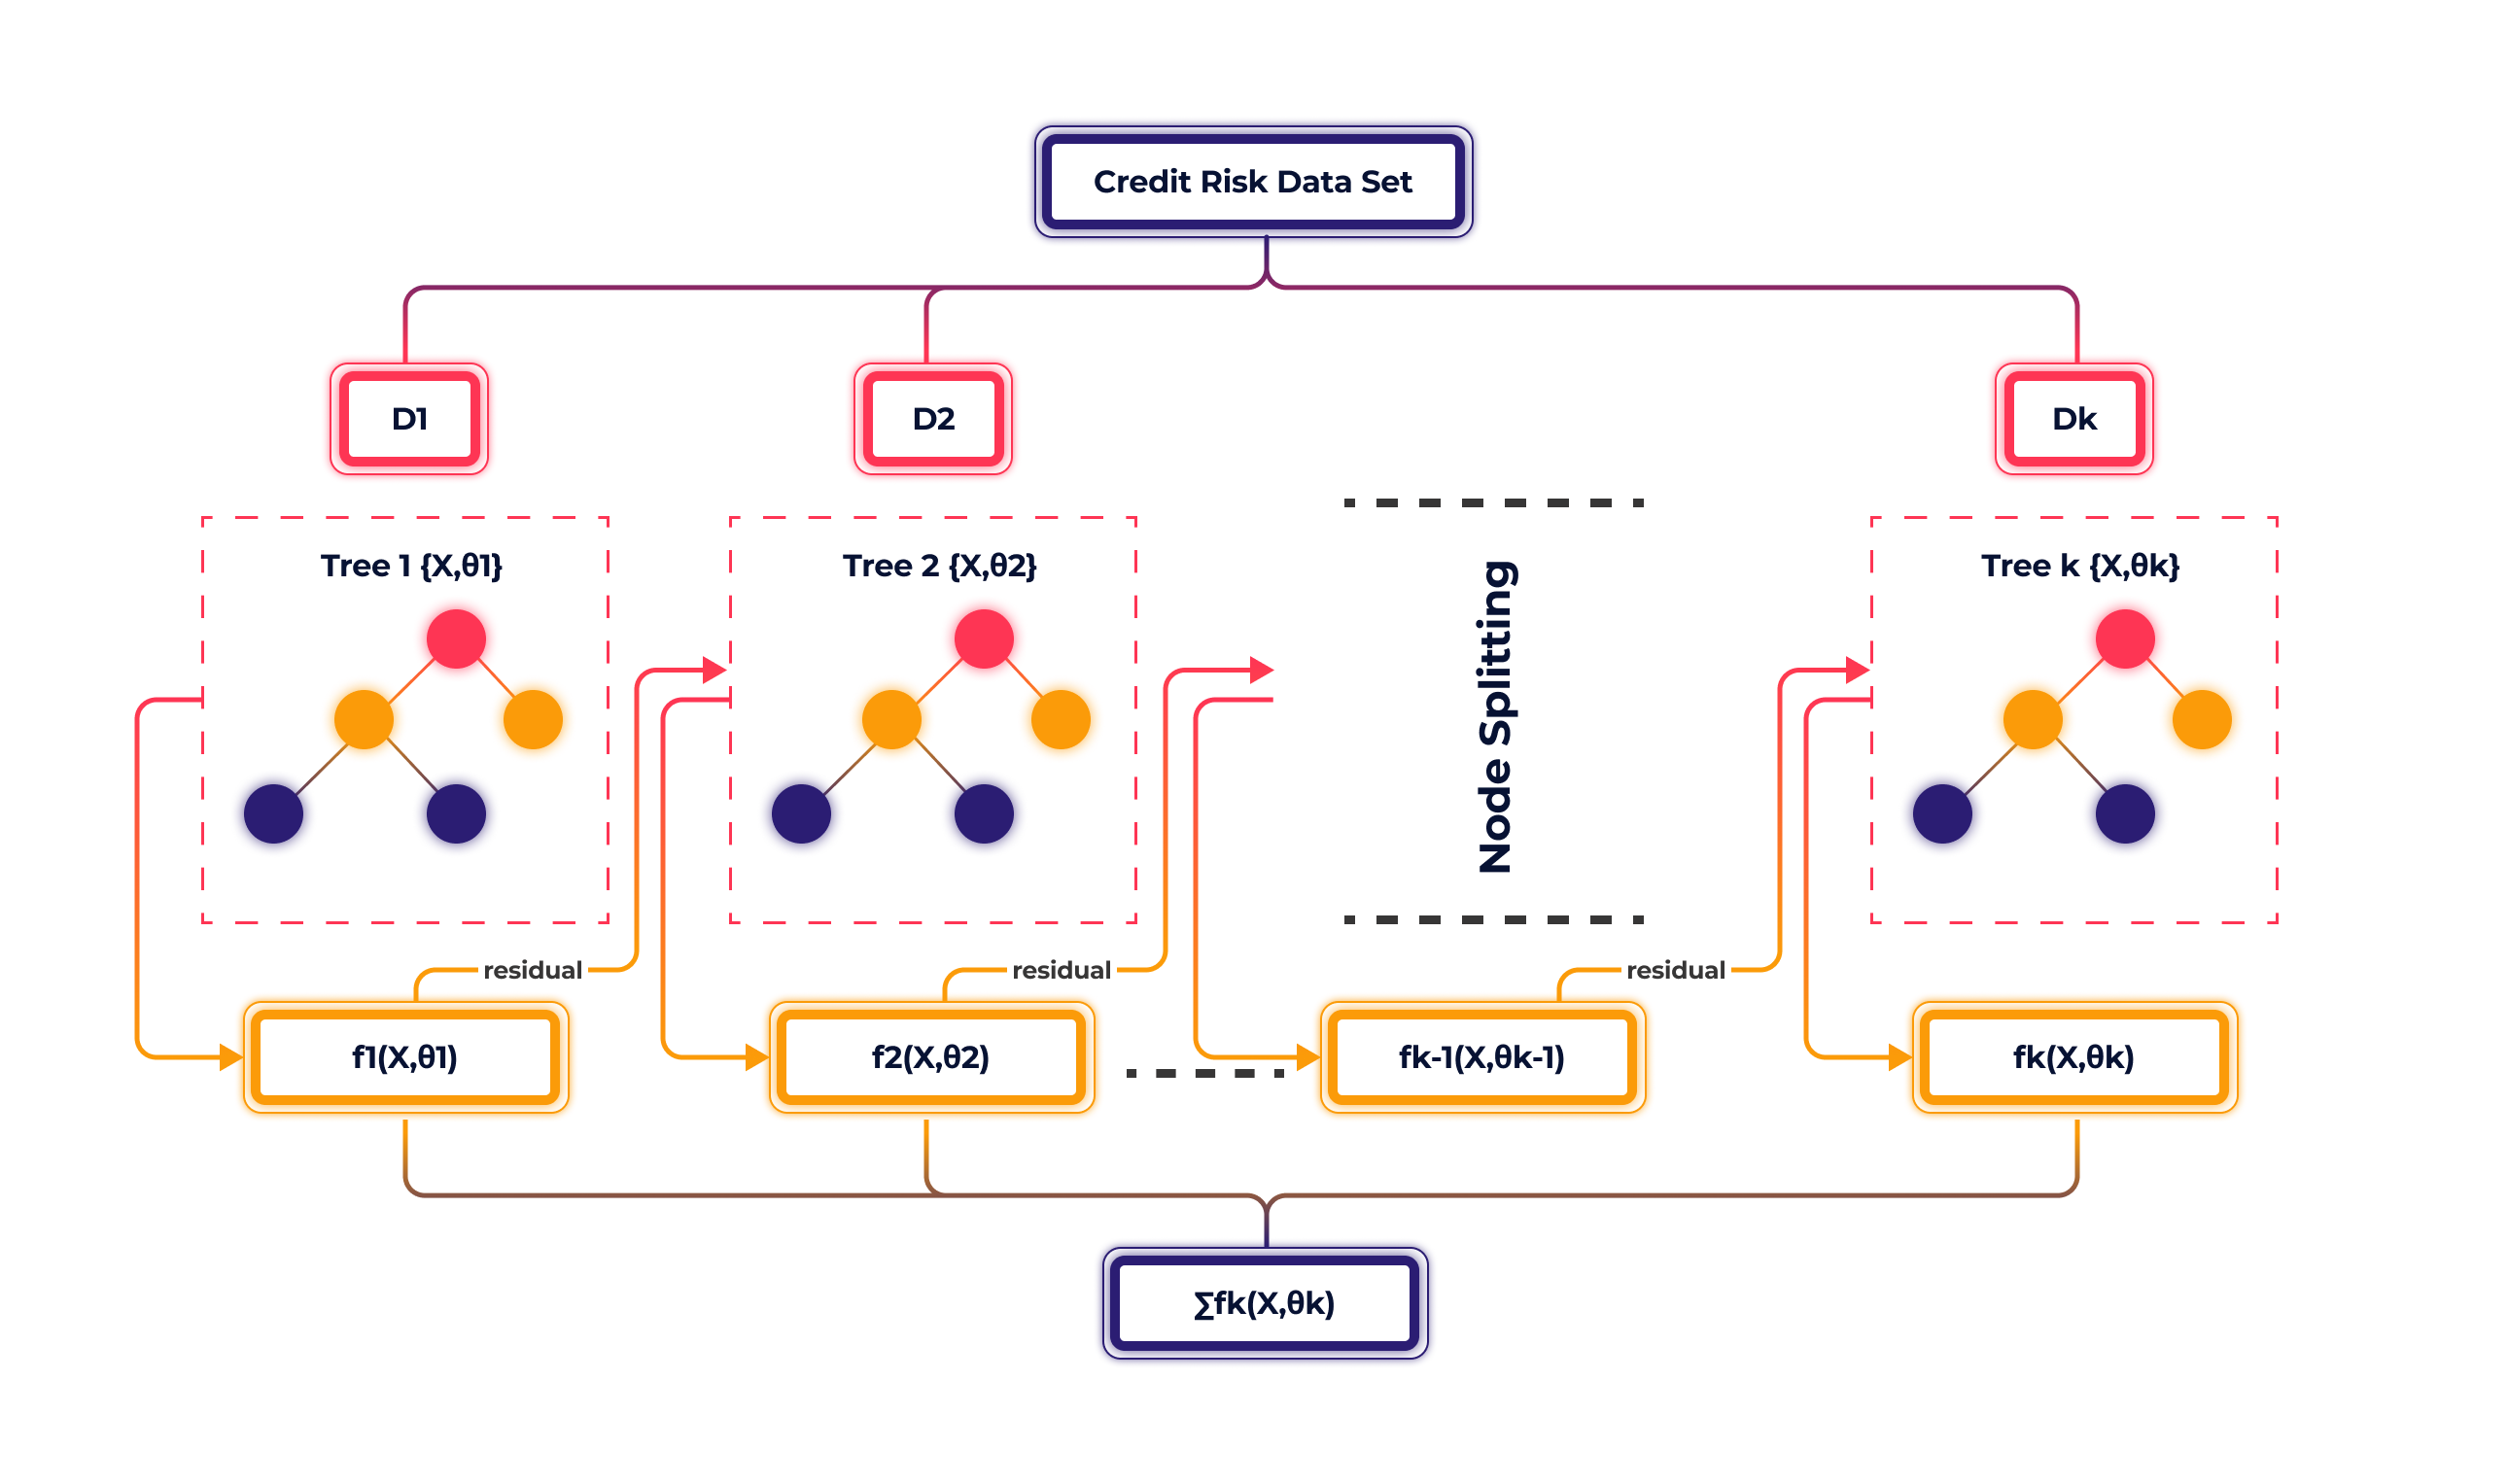

__Referensi :__

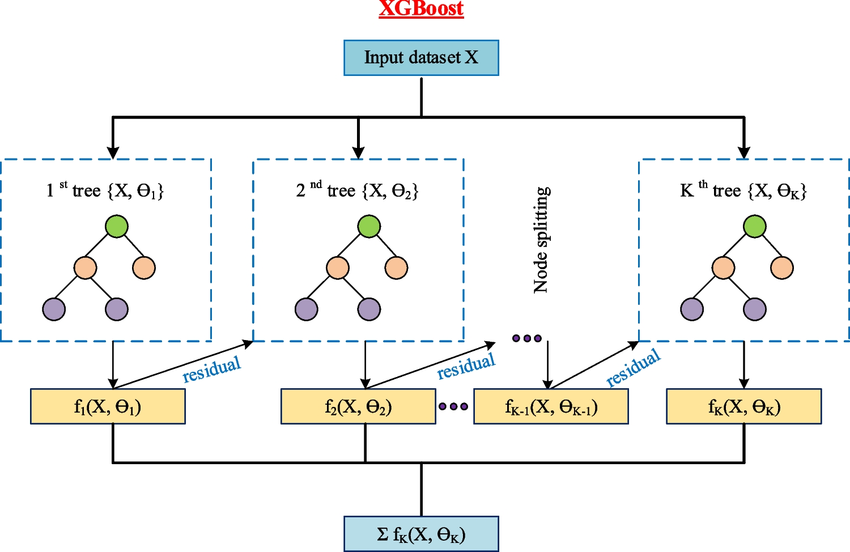

1. __Credit Risk Dataset :__ Prosesnya dimulai dengan menginput Credit Risk Dataset, yang merupakan kumpulan fitur yang akan digunakan untuk membangun model nanti.

2. __Ensemble Learning dengan Decision Tree :__ XGBoost adalah algoritma yang berbasis boosting, yang berarti dia membangun model secara bertahap. Model ini terdiri dari beberapa pohon keputusan (decision trees) yang bekerja sama untuk membuat prediksi yang lebih akurat. Di gambar, kita bisa lihat ada beberapa pohon yang dilabeli Tree1, Tree2, ..., Tree
k, yang menunjukkan bahwa model ini terdiri dari kumpulan pohon yang terus berkembang.

3. __Residual dan Pembelajaran Bertahap :__ Setelah satu pohon dibuat, model akan menghitung residual error, yaitu selisih antara prediksi model dengan nilai asli yang seharusnya. Pohon berikutnya kemudian dibangun untuk memperbaiki kesalahan ini. Proses ini berlangsung secara bertahap, di mana setiap pohon baru berusaha mengurangi kesalahan dari pohon sebelumnya.

4. __Prediksi Akhir :__ Setelah semua pohon dibuat, hasil akhirnya bukan cuma dari satu pohon saja, tapi merupakan gabungan dari semua pohon yang telah dilatih. Secara matematis, hasil prediksi model ini bisa dituliskan sebagai
∑
𝑓
𝑘
(
𝑋
,
𝜃
𝑘
)
 yang berarti semua output dari setiap pohon dijumlahkan untuk menghasilkan prediksi akhir. Dengan cara ini, model bisa memberikan hasil yang jauh lebih akurat dibandingkan hanya mengandalkan satu pohon saja.


 Jadi, __XGBoost (Extreme Gradient Boosting)__ adalah algoritma pembelajaran mesin berbasis ensemble yang dirancang untuk meningkatkan akurasi prediksi melalui penggabungan sejumlah pohon keputusan. Algoritma ini dikenal karena efisiensinya dalam komputasi dan kemampuannya menangani berbagai jenis data, termasuk yang memiliki ketidakseimbangan kelas.

__Alasan Menggunakan XGBoost:__

1. __Efisiensi dan Skalabilitas:__ XGBoost dirancang untuk efisiensi komputasi tinggi, mampu menangani dataset besar dengan cepat.
2. __Regularisasi:__ Algoritma ini memiliki mekanisme regularisasi bawaan yang membantu mencegah overfitting, memastikan model generalisasi dengan baik pada data baru.
3. __Kinerja Unggul:__ Studi menunjukkan bahwa XGBoost sering kali mengungguli algoritma lain dalam tugas klasifikasi, termasuk prediksi risiko kredit. Misalnya, penelitian oleh Chen dan Guestrin (2016) menunjukkan bahwa XGBoost menawarkan kinerja dan efisiensi yang superior dalam berbagai aplikasi.

## __FLOWCHART__

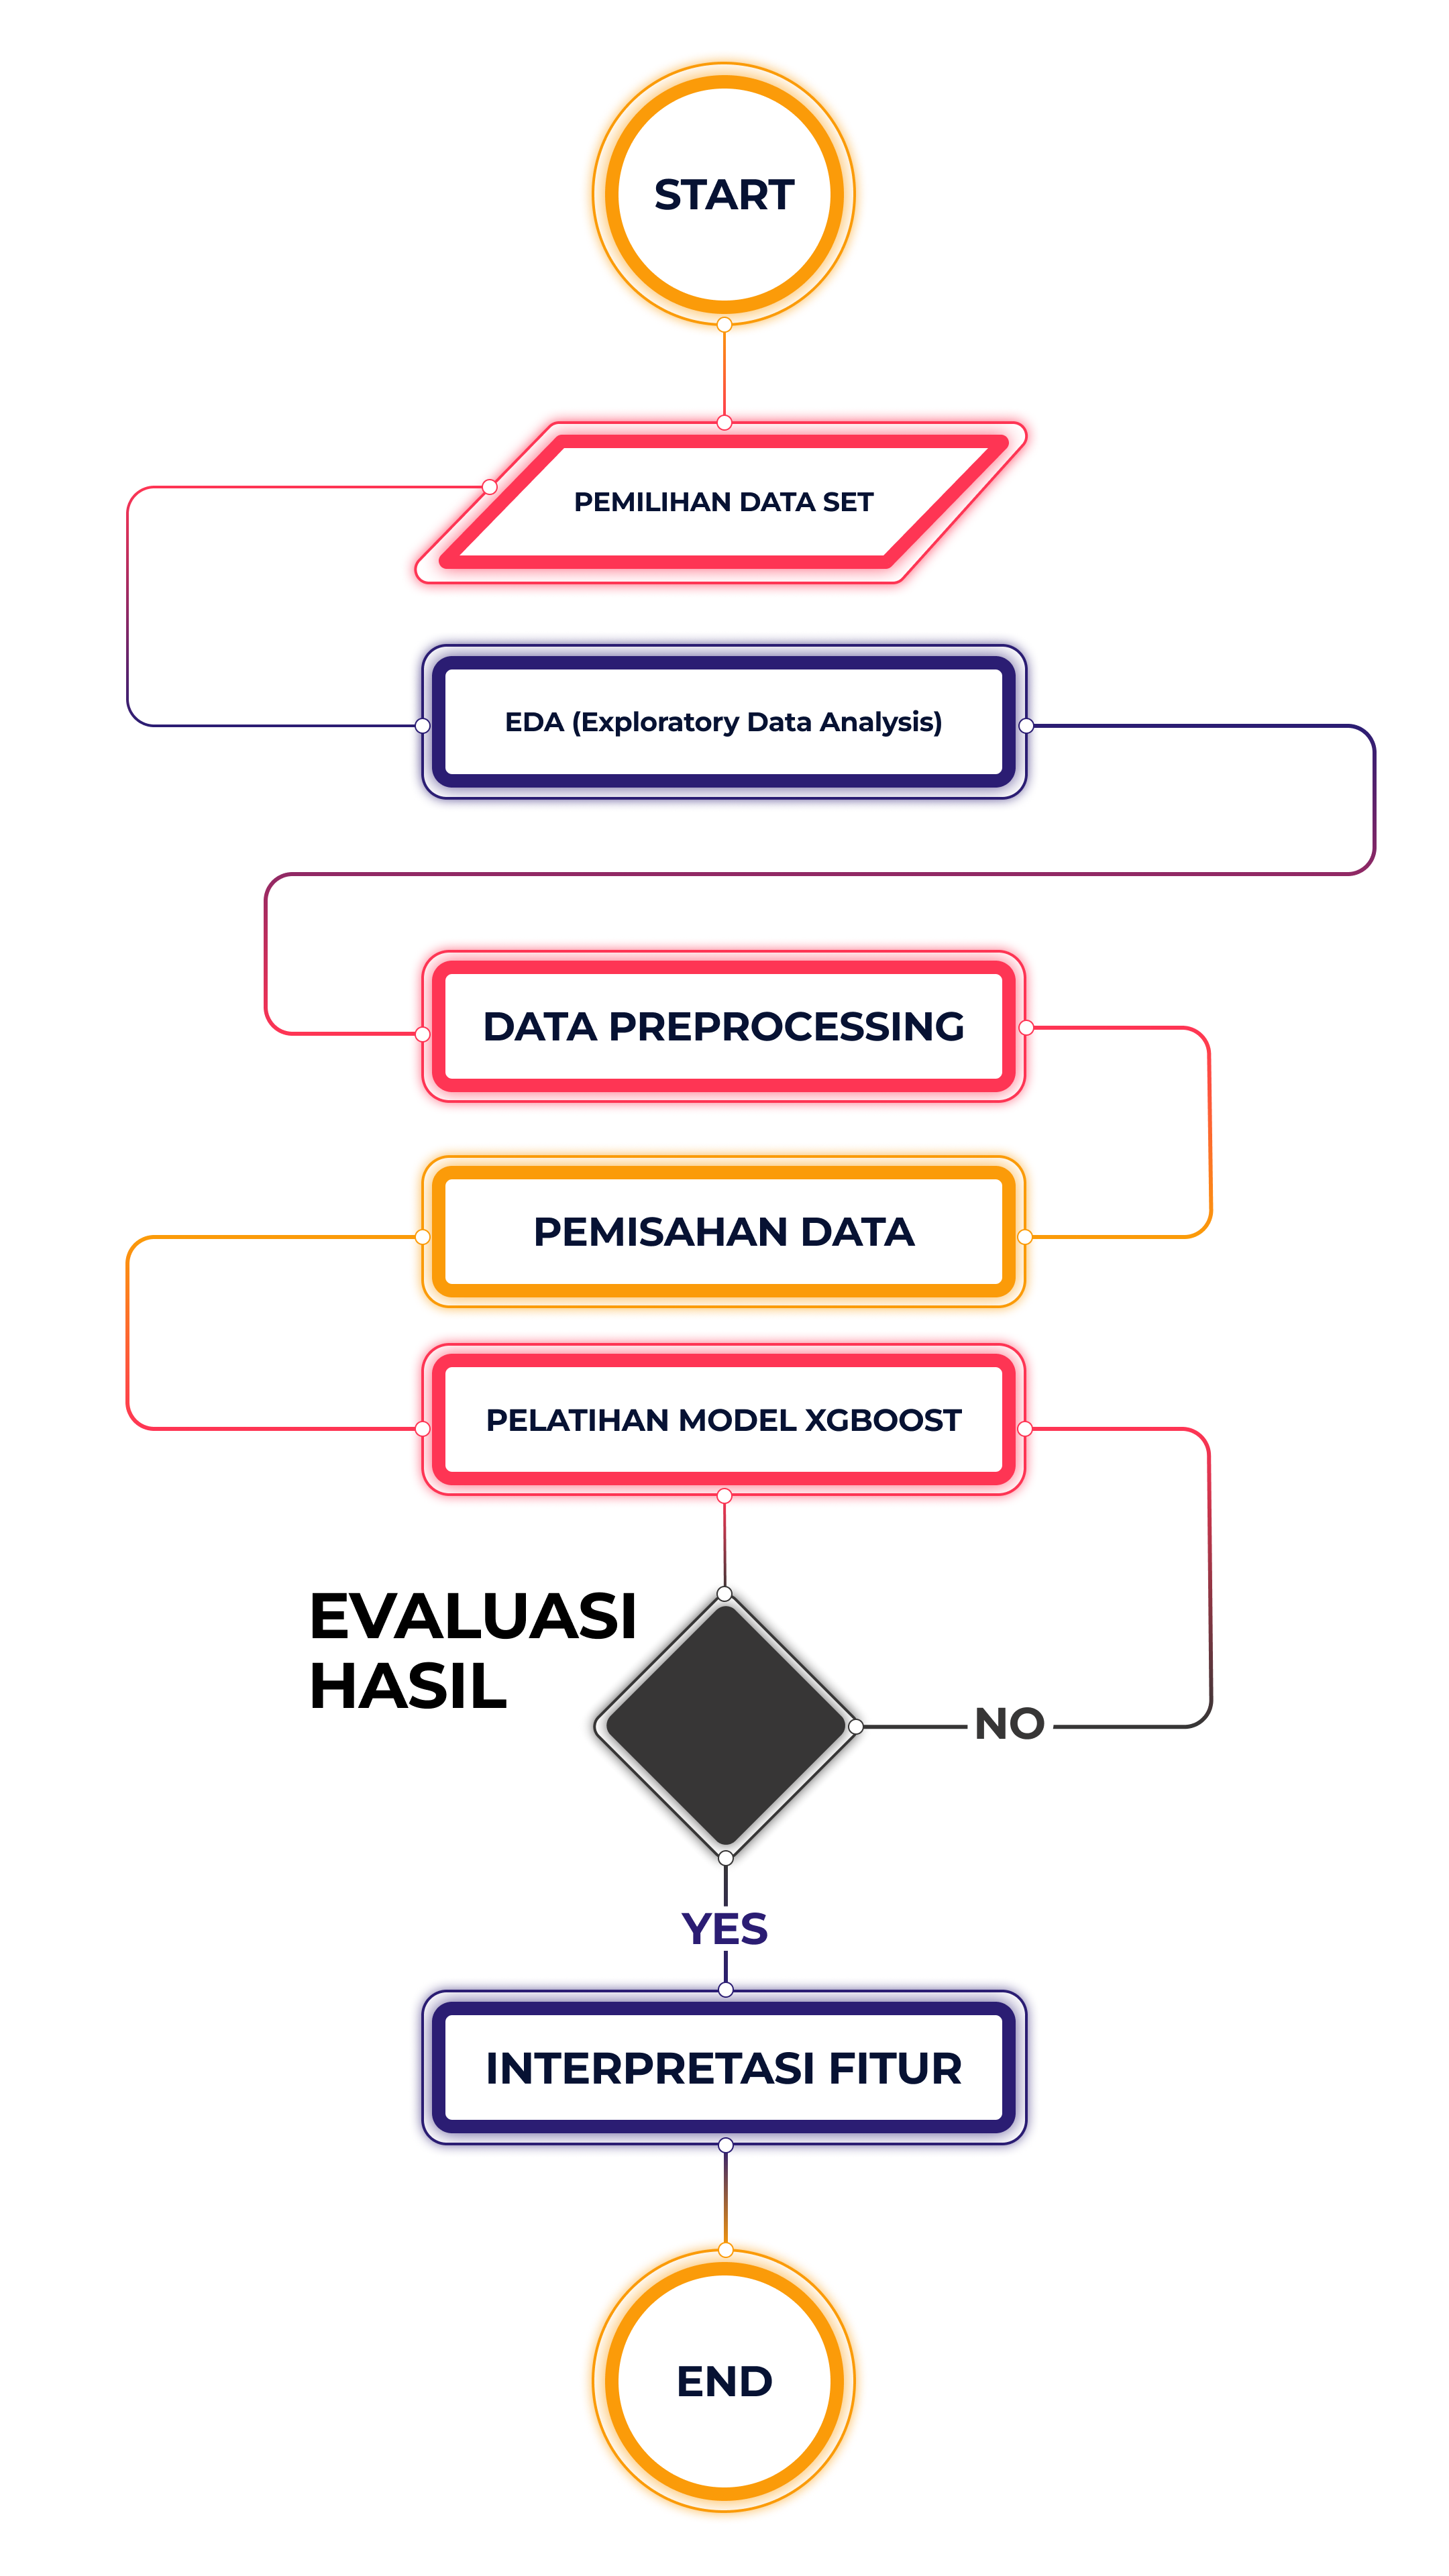

Berikut adalah penjelasan metodologi flowchart :

1. __Pemilihan Dataset__
Tahap awal dalam proses ini adalah pemilihan dataset yang berkaitan dengan risiko kredit. Dataset ini berisi informasi penting seperti usia peminjam, pendapatan, status kepemilikan rumah, tujuan pinjaman, jumlah pinjaman, dan tingkat bunga. Pemilihan dataset ini didasarkan pada relevansi fitur-fitur tersebut dalam memprediksi kemungkinan terjadinya kredit bermasalah. Dataset yang tepat akan membantu proses analisis dan pemodelan berjalan dengan optimal.

2. __EDA (Exploratory Data Analysis)__
Setelah dataset dipilih, dilakukan proses EDA untuk memahami struktur dan karakteristik data. Analisis ini mencakup identifikasi nilai yang hilang, outlier, dan distribusi data. Selain itu, analisis korelasi antara variabel juga dilakukan untuk mengetahui hubungan antar fitur. Proses EDA ini penting untuk memberikan gambaran awal terkait kualitas data dan potensi permasalahan yang mungkin muncul di tahap selanjutnya.

3. __Preprocessing Data__
Tahap ini berfokus pada pembersihan dan persiapan data agar dapat digunakan dengan optimal oleh model machine learning. Langkah-langkah yang dilakukan meliputi penanganan data yang hilang, penghapusan outlier, serta encoding variabel kategorikal menjadi numerik. Normalisasi atau penskalaan fitur juga dapat dilakukan untuk memastikan semua variabel memiliki skala yang seragam. Proses preprocessing ini bertujuan untuk menghasilkan data yang bersih dan siap digunakan dalam pelatihan model.

4. __Pemisahan Data (Split Data)__
Setelah data siap, dataset akan dibagi menjadi dua bagian utama, yaitu data pelatihan (training data) dan data pengujian (testing data). Umumnya, pembagian ini menggunakan rasio 80:20, di mana 80% data digunakan untuk melatih model dan 20% sisanya digunakan untuk menguji kinerja model. Tahap ini bertujuan untuk menghindari overfitting dan memastikan bahwa model dapat memprediksi data baru dengan baik.

5. __Pelatihan Model XGBoost__
Pada tahap ini, model XGBoost akan dilatih menggunakan data pelatihan. XGBoost dipilih karena kemampuannya dalam menangani dataset yang kompleks dengan efisien dan akurat. Proses pelatihan melibatkan penyesuaian parameter model untuk mendapatkan performa terbaik. Model akan belajar dari pola-pola yang ada di data pelatihan sehingga dapat digunakan untuk melakukan prediksi pada data baru.

6. __Evaluasi Model__
Evaluasi model dilakukan menggunakan data pengujian untuk mengukur seberapa baik model yang telah dilatih. Berbagai metrik evaluasi, seperti akurasi, precision, recall, dan F1-score, akan digunakan untuk menilai kinerja model. Hasil evaluasi ini akan menunjukkan apakah model dapat memprediksi risiko kredit dengan akurat dan andal. Jika diperlukan, proses tuning parameter dapat dilakukan untuk meningkatkan performa model.

7. __Interpretasi Fitur__
Tahap terakhir adalah interpretasi fitur untuk mengidentifikasi variabel mana yang memiliki pengaruh paling signifikan dalam proses prediksi. Interpretasi ini penting untuk memahami faktor-faktor utama yang memengaruhi risiko kredit. Dengan demikian, hasil analisis dapat memberikan wawasan yang berguna bagi pengambilan keputusan di masa mendatang.

# __WEEK-6 DAN 7 PELATIHAN DAN VALIDASI: MEMBANGUN MODEL__

## _Splitting Training, Validating, Testing Dataset_
Membagi dataset menjadi tiga bagian: data latih (70%), data validasi (15%), dan data uji (15%) dengan memastikan distribusi target variabel (loan_status) tetap konsisten di setiap bagian. Pembagian dilakukan dua kali menggunakan fungsi train_test_split, dan ukuran setiap data set kemudian dicetak untuk memverifikasi distribusinya. Tujuannya adalah untuk mempersiapkan data bagi proses pelatihan model machine learning.

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X = df_balanced.drop(columns=['loan_status'])
y = df_balanced['loan_status']

In [63]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [64]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [65]:
# Cek ukuran dataset
print("Distribusi Data Train:", X_train.shape)
print("Distribusi Data Val:", X_val.shape)
print("Distribusi Data Test:", X_test.shape)

Distribusi Data Train: (34203, 29)
Distribusi Data Val: (7329, 29)
Distribusi Data Test: (7330, 29)


## _Membangun Model XGBoost Classifier (Sebelum Tuning)_
Melatih dan menguji model XGBoost dalam melakukan klasifikasi. Model ini dilatih menggunakan data latih dan data validasi untuk mengoptimalkan kinerjanya, dan kemudian digunakan untuk memprediksi hasil pada tiga set data yang berbeda: data latih, data validasi, dan data uji. Dengan demikian, kode ini bertujuan untuk melatih model, memantau kinerjanya, dan menghasilkan prediksi untuk evaluasi lebih lanjut.

In [66]:
from xgboost import XGBClassifier

# Inisialisasi model XGBoost
XGB = XGBClassifier(random_state=42)

# Latih model dengan data training dan validasi
XGB.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=True)

# Prediksi pada data test dan validation
y_pred_val = XGB.predict(X_val)
y_pred_test = XGB.predict(X_test)
y_pred_train = XGB.predict(X_train)

[0]	validation_0-logloss:0.53906	validation_1-logloss:0.53619
[1]	validation_0-logloss:0.44571	validation_1-logloss:0.44182
[2]	validation_0-logloss:0.39033	validation_1-logloss:0.38553
[3]	validation_0-logloss:0.35346	validation_1-logloss:0.34827
[4]	validation_0-logloss:0.32695	validation_1-logloss:0.32139
[5]	validation_0-logloss:0.30804	validation_1-logloss:0.30216
[6]	validation_0-logloss:0.28897	validation_1-logloss:0.28339
[7]	validation_0-logloss:0.27711	validation_1-logloss:0.27155
[8]	validation_0-logloss:0.26685	validation_1-logloss:0.26224
[9]	validation_0-logloss:0.25470	validation_1-logloss:0.24915
[10]	validation_0-logloss:0.24738	validation_1-logloss:0.24257
[11]	validation_0-logloss:0.23559	validation_1-logloss:0.23099
[12]	validation_0-logloss:0.22915	validation_1-logloss:0.22516
[13]	validation_0-logloss:0.22431	validation_1-logloss:0.22076
[14]	validation_0-logloss:0.21497	validation_1-logloss:0.21183
[15]	validation_0-logloss:0.21097	validation_1-logloss:0.20802
[1

## _Mengevaluasi Model XGBoost Classifier (Sebelum Tuning)_

### _Confusion Matrix Data Test_
Menghitung akurasi model pada __data uji (y_test dan y_pred_test)__, menampilkan confusion matrix, dan memvisualisasikannya menggunakan heatmap. Selain itu, kode ini juga mencetak classification report, yang memberikan metrik evaluasi lainnya seperti precision, recall, dan F1-score untuk model pada data uji.

Untuk __data uji (test)__, model berhasil memprediksi __3372 True Positive (TP)__ dan __3624 True Negative (TN)__ dengan akurasi yang tinggi. Namun, ada __41 False Positive (FP)__ dan __293 False Negative (FN)__, yang menunjukkan adanya kesalahan dalam klasifikasi beberapa data.

In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [68]:
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Akurasi: {accuracy:.2f}")

Akurasi: 0.95


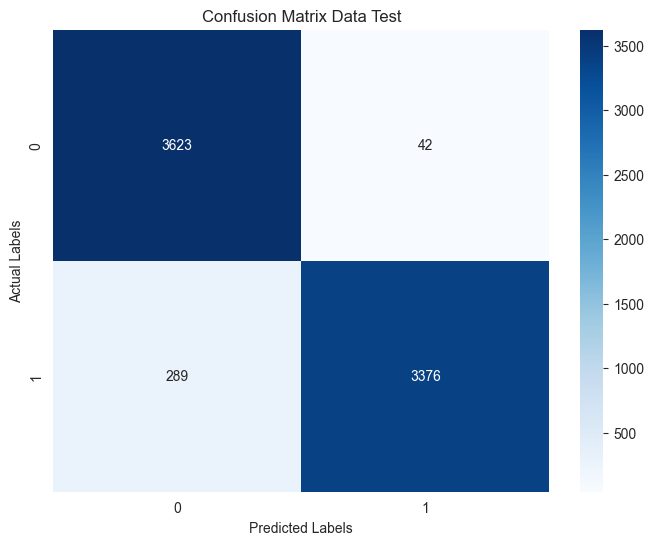

In [69]:
# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Membuat visualisasi dari confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Data Test")
plt.show()

In [70]:
# Hitung confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Ekstrak nilai TP, TN, FP, FN
TN, FP, FN, TP = conf_matrix.ravel()

# Print TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positive (TP): 3376
True Negative (TN): 3623
False Positive (FP): 42
False Negative (FN): 289


In [71]:
print("Classification Report:\n\n", classification_report(y_test, y_pred_test))

Classification Report:

               precision    recall  f1-score   support

           0       0.93      0.99      0.96      3665
           1       0.99      0.92      0.95      3665

    accuracy                           0.95      7330
   macro avg       0.96      0.95      0.95      7330
weighted avg       0.96      0.95      0.95      7330



### _Confusion Matrix Data Train_
Menghitung akurasi model pada data latih (y_train dan y_pred_train). Akurasi dihitung, confusion matrix divisualisasikan, dan classification report ditampilkan untuk menilai kinerja model pada data yang digunakan untuk pelatihan.

Pada __data latih (train)__, model menunjukkan hasil yang lebih baik dengan __16054 TP__ dan __17068 TN__, sementara hanya terdapat __33 FP__ dan __1048 FN__, menunjukkan performa model yang sangat baik pada data yang digunakan untuk pelatihan.

In [72]:
accuracy = accuracy_score(y_train, y_pred_train)
print(f"Akurasi: {accuracy:.2f}")

Akurasi: 0.97


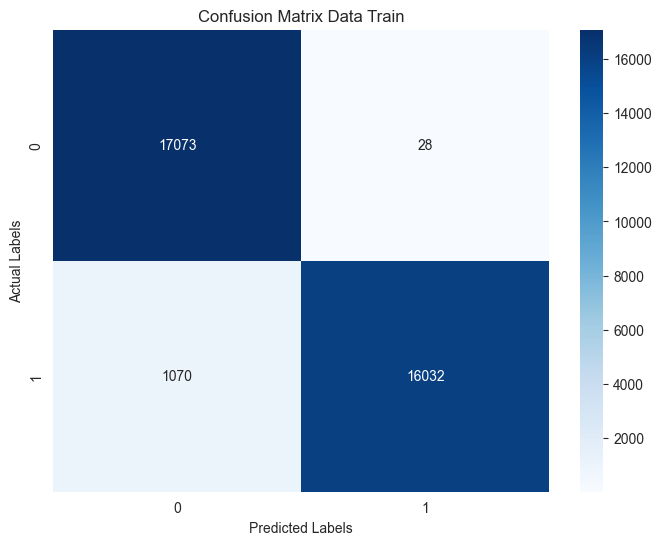

In [73]:
# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Membuat visualisasi dari confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Data Train")
plt.show()

In [74]:
# Hitung confusion matrix
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Ekstrak nilai TP, TN, FP, FN
TN, FP, FN, TP = conf_matrix.ravel()

# Print TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positive (TP): 16032
True Negative (TN): 17073
False Positive (FP): 28
False Negative (FN): 1070


In [75]:
print("Classification Report:\n\n", classification_report(y_train, y_pred_train))

Classification Report:

               precision    recall  f1-score   support

           0       0.94      1.00      0.97     17101
           1       1.00      0.94      0.97     17102

    accuracy                           0.97     34203
   macro avg       0.97      0.97      0.97     34203
weighted avg       0.97      0.97      0.97     34203



### _Confusion Matrix Data Validation_
Menghitung akurasi model pada __data validasi (y_val dan y_pred_val)__, menghitung akurasi, memvisualisasikan confusion matrix, dan mencetak classification report untuk data validasi.

Pada __data validasi (validation)__, model memprediksi __3401 True Positive (TP)__ dan __3617 True Negative (TN)__ dengan __48 False Positive (FP)__ dan __263 False Negative (FN)__.

In [76]:
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Akurasi: {accuracy:.2f}")

Akurasi: 0.96


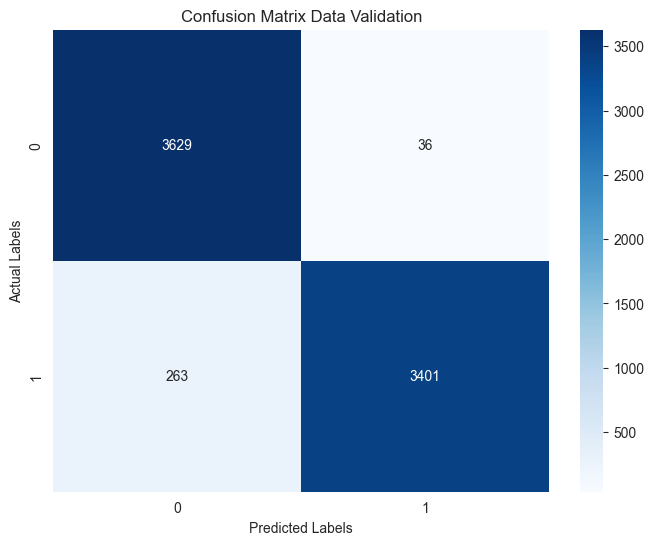

In [77]:
# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred_val)

# Membuat visualisasi dari confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Data Validation")
plt.show()

In [78]:
# Hitung confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred_val)

# Ekstrak nilai TP, TN, FP, FN
TN, FP, FN, TP = conf_matrix.ravel()

# Print TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positive (TP): 3401
True Negative (TN): 3629
False Positive (FP): 36
False Negative (FN): 263


In [79]:
print("Classification Report:\n\n", classification_report(y_val, y_pred_val))

Classification Report:

               precision    recall  f1-score   support

           0       0.93      0.99      0.96      3665
           1       0.99      0.93      0.96      3664

    accuracy                           0.96      7329
   macro avg       0.96      0.96      0.96      7329
weighted avg       0.96      0.96      0.96      7329



### _Plot Learning Curve_

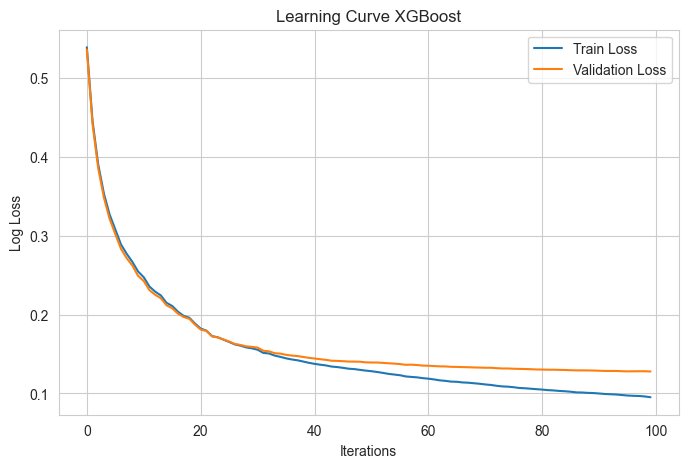

In [80]:
# Plot Learning Curve
results = XGB.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['logloss'], label='Train Loss')
if 'validation_1' in results:
    plt.plot(results['validation_1']['logloss'], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('Learning Curve XGBoost')
plt.legend()
plt.show()

### _Prediksi Probabilitas untuk Training, Testing dan Validation Set_

In [81]:
from sklearn.metrics import roc_auc_score

# Prediksi probabilitas untuk tiap set
train_pred_proba = XGB.predict_proba(X_train)[:, 1]
val_pred_proba = XGB.predict_proba(X_val)[:, 1]
test_pred_proba = XGB.predict_proba(X_test)[:, 1]

# Hitung AUC
train_auc = roc_auc_score(y_train, train_pred_proba)
val_auc = roc_auc_score(y_val, val_pred_proba)
test_auc = roc_auc_score(y_test, test_pred_proba)

print(f"Train AUC: {train_auc}")
print(f"Validation AUC: {val_auc}")
print(f"Test AUC: {test_auc}")

Train AUC: 0.9952292799407697
Validation AUC: 0.9846082528580875
Test AUC: 0.9836511821384766


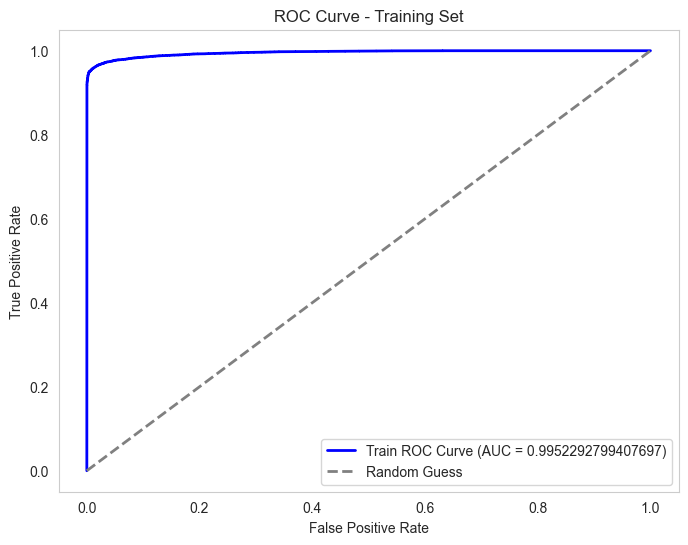

In [82]:
# Plot ROC Curve untuk Training Set
fpr, tpr, _ = roc_curve(y_train, train_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Train ROC Curve (AUC = {train_auc})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

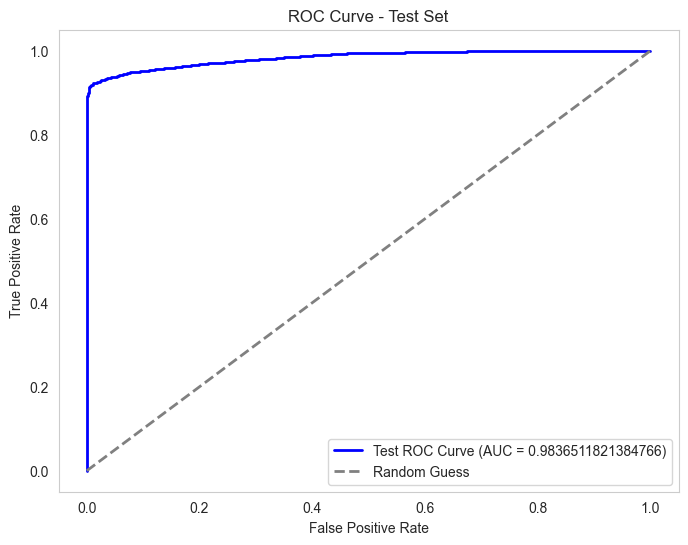

In [83]:
# Plot ROC Curve untuk Test Set
fpr, tpr, _ = roc_curve(y_test, test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Test ROC Curve (AUC = {test_auc})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

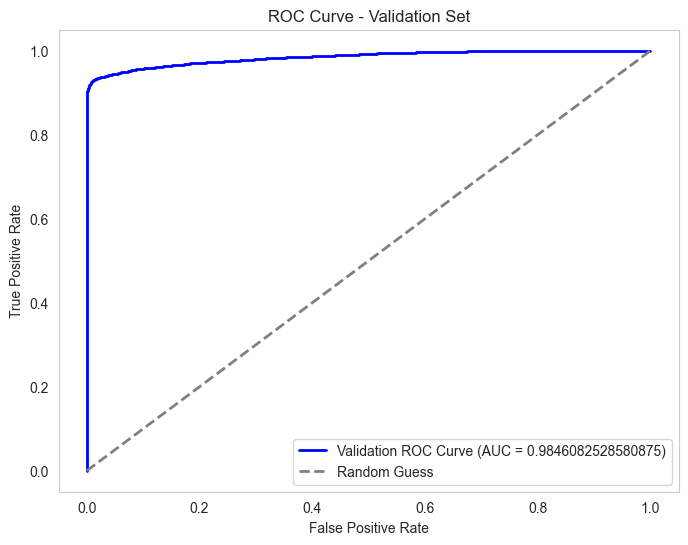

In [84]:
# Plot ROC Curve untuk Validation Set
fpr, tpr, _ = roc_curve(y_val, val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Validation ROC Curve (AUC = {val_auc})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# __WEEK- OPTIMASI HYPERPARAMETER DAN FINE TUNING EVALUASI__

## _OPTIMASI HYPERPARAMETER_

In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'max_depth': [3, 5, 7], 
    'n_estimators': [50, 100, 150, 200, 300, 500],
    'subsample': [0.8, 1.0], 
    'colsample_bytree': [0.8, 1.0],
}

In [88]:
from sklearn.model_selection import GridSearchCV

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', tree_method="hist")

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:12:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 150, 200, 300, 500],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')

In [89]:
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
Best score: 0.9536298940598096


## _Fine-Tuning Evaluasi Model_

In [ ]:
best_params = grid_search.best_params_

# Train final model dengan early stopping
final_model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric="logloss", tree_method="hist")
final_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=True)

[0]	validation_0-logloss:0.64393	validation_1-logloss:0.64361
[1]	validation_0-logloss:0.59256	validation_1-logloss:0.59153
[2]	validation_0-logloss:0.55075	validation_1-logloss:0.54903
[3]	validation_0-logloss:0.51505	validation_1-logloss:0.51320


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:58:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[4]	validation_0-logloss:0.48480	validation_1-logloss:0.48244
[5]	validation_0-logloss:0.45669	validation_1-logloss:0.45435
[6]	validation_0-logloss:0.43463	validation_1-logloss:0.43186
[7]	validation_0-logloss:0.41478	validation_1-logloss:0.41191
[8]	validation_0-logloss:0.39740	validation_1-logloss:0.39470
[9]	validation_0-logloss:0.38576	validation_1-logloss:0.38322
[10]	validation_0-logloss:0.37099	validation_1-logloss:0.36838
[11]	validation_0-logloss:0.35992	validation_1-logloss:0.35746
[12]	validation_0-logloss:0.34984	validation_1-logloss:0.34772
[13]	validation_0-logloss:0.33945	validation_1-logloss:0.33724
[14]	validation_0-logloss:0.33076	validation_1-logloss:0.32839
[15]	validation_0-logloss:0.32199	validation_1-logloss:0.31990
[16]	validation_0-logloss:0.31544	validation_1-logloss:0.31375
[17]	validation_0-logloss:0.30686	validation_1-logloss:0.30513
[18]	validation_0-logloss:0.29832	validation_1-logloss:0.29589
[19]	validation_0-logloss:0.28962	validation_1-logloss:0.2874

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

## _Mengevaluasi Model XGBoost Classifier (Setelah Tuning)_

In [120]:
y_pred_test = final_model.predict(X_test)
y_pred_train = final_model.predict(X_train)
y_pred_val = final_model.predict(X_val)


### _Confusion Matrix Data Test_

In [121]:
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Akurasi: {accuracy: .2f}")

Akurasi:  0.96


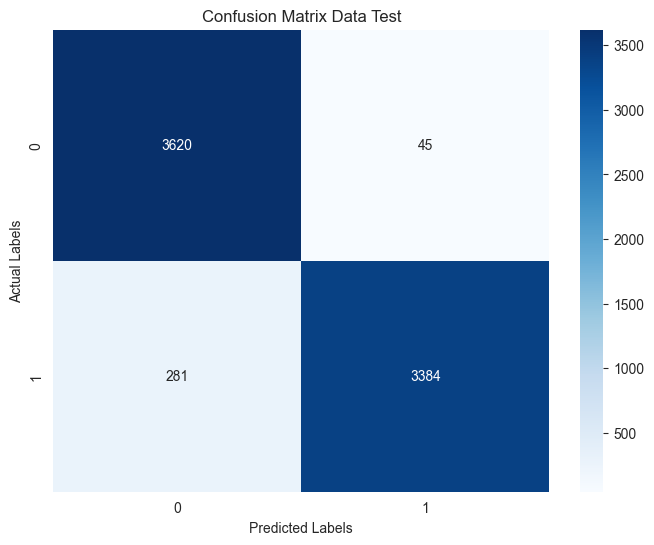

In [122]:
# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Membuat visualisasi dari confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Data Test")
plt.show()

In [123]:
# Hitung confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Ekstrak nilai TP, TN, FP, FN
TN, FP, FN, TP = conf_matrix.ravel()

# Print TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positive (TP): 3384
True Negative (TN): 3620
False Positive (FP): 45
False Negative (FN): 281


In [124]:
print("Classification Report:\n\n", classification_report(y_test, y_pred_test))

Classification Report:

               precision    recall  f1-score   support

           0       0.93      0.99      0.96      3665
           1       0.99      0.92      0.95      3665

    accuracy                           0.96      7330
   macro avg       0.96      0.96      0.96      7330
weighted avg       0.96      0.96      0.96      7330



### _Confusion Matrix Data Train_

In [125]:
accuracy = accuracy_score(y_train, y_pred_train)
print(f"Akurasi: {accuracy:.2f}")

Akurasi: 0.99


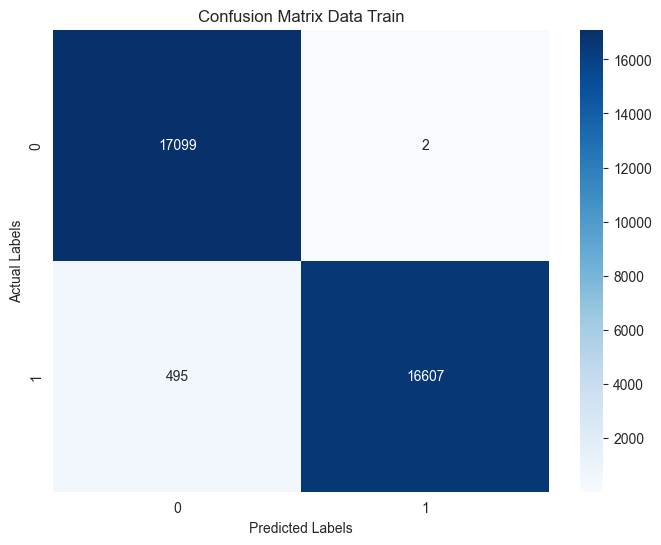

In [126]:
# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Membuat visualisasi dari confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Data Train")
plt.show()

In [127]:
# Hitung confusion matrix
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Ekstrak nilai TP, TN, FP, FN
TN, FP, FN, TP = conf_matrix.ravel()

# Print TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positive (TP): 16607
True Negative (TN): 17099
False Positive (FP): 2
False Negative (FN): 495


In [128]:
print("Classification Report:\n\n", classification_report(y_train, y_pred_train))

Classification Report:

               precision    recall  f1-score   support

           0       0.97      1.00      0.99     17101
           1       1.00      0.97      0.99     17102

    accuracy                           0.99     34203
   macro avg       0.99      0.99      0.99     34203
weighted avg       0.99      0.99      0.99     34203



### _Confusion Matrix Data Validation_

In [129]:
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Akurasi: {accuracy:.2f}")

Akurasi: 0.96


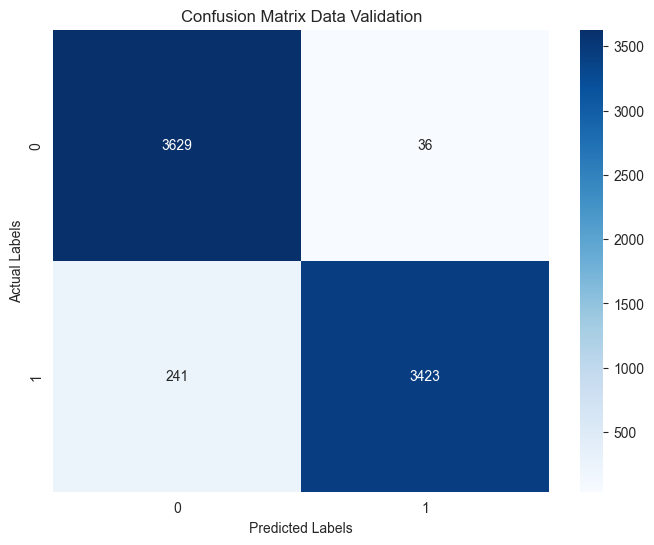

In [130]:
# Menampilkan confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred_val)

# Membuat visualisasi dari confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix Data Validation")
plt.show()

In [131]:
# Hitung confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred_val)

# Ekstrak nilai TP, TN, FP, FN
TN, FP, FN, TP = conf_matrix.ravel()

# Print TP, TN, FP, FN
print(f"True Positive (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positive (TP): 3423
True Negative (TN): 3629
False Positive (FP): 36
False Negative (FN): 241


In [132]:
print("Classification Report:\n\n", classification_report(y_val, y_pred_val))

Classification Report:

               precision    recall  f1-score   support

           0       0.94      0.99      0.96      3665
           1       0.99      0.93      0.96      3664

    accuracy                           0.96      7329
   macro avg       0.96      0.96      0.96      7329
weighted avg       0.96      0.96      0.96      7329



### _Plot Learning Curve_

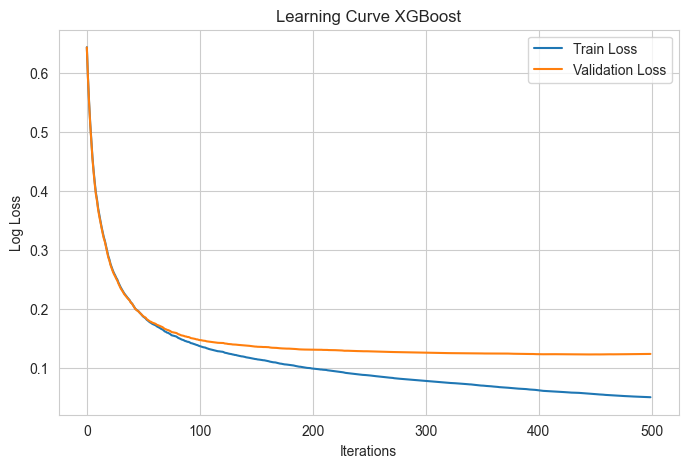

In [133]:
# Plot Learning Curve
results = final_model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['logloss'], label='Train Loss')
if 'validation_1' in results:
    plt.plot(results['validation_1']['logloss'], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('Learning Curve XGBoost')
plt.legend()
plt.show()

### _Prediksi Probabilitas untuk Training, Testing dan Validation Set_

In [134]:
# Prediksi probabilitas untuk tiap set
train_pred_proba = final_model.predict_proba(X_train)[:, 1]
val_pred_proba = final_model.predict_proba(X_val)[:, 1]
test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Hitung AUC
train_auc = roc_auc_score(y_train, train_pred_proba)
val_auc = roc_auc_score(y_val, val_pred_proba)
test_auc = roc_auc_score(y_test, test_pred_proba)

print(f"Train AUC: {train_auc}")
print(f"Validation AUC: {val_auc}")
print(f"Test AUC: {test_auc}")

Train AUC: 0.9998520351249751
Validation AUC: 0.9840759545327273
Test AUC: 0.9858401716766954


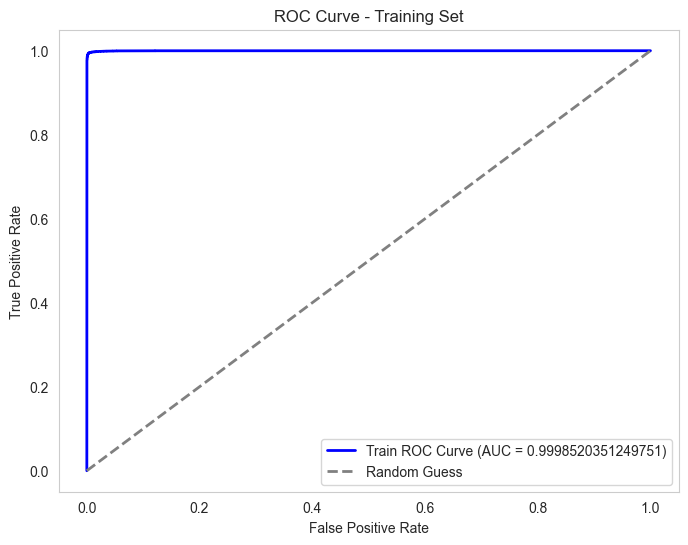

In [135]:
# Plot ROC Curve untuk Training Set
fpr, tpr, _ = roc_curve(y_train, train_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Train ROC Curve (AUC = {train_auc})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

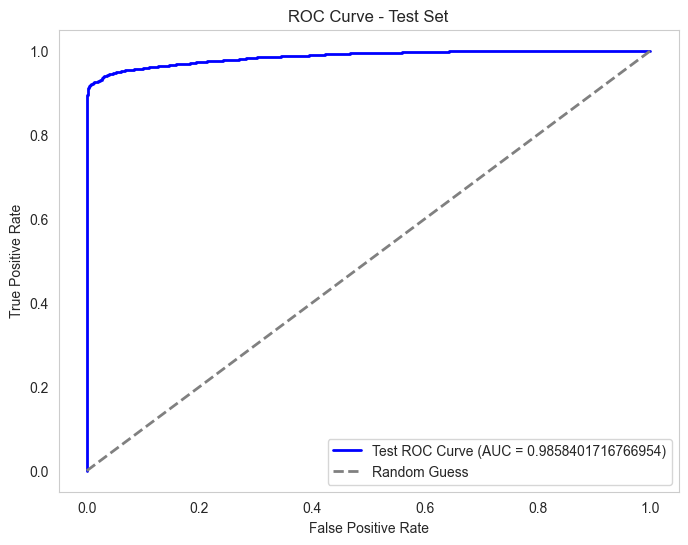

In [136]:
# Plot ROC Curve untuk Test Set
fpr, tpr, _ = roc_curve(y_test, test_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Test ROC Curve (AUC = {test_auc})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

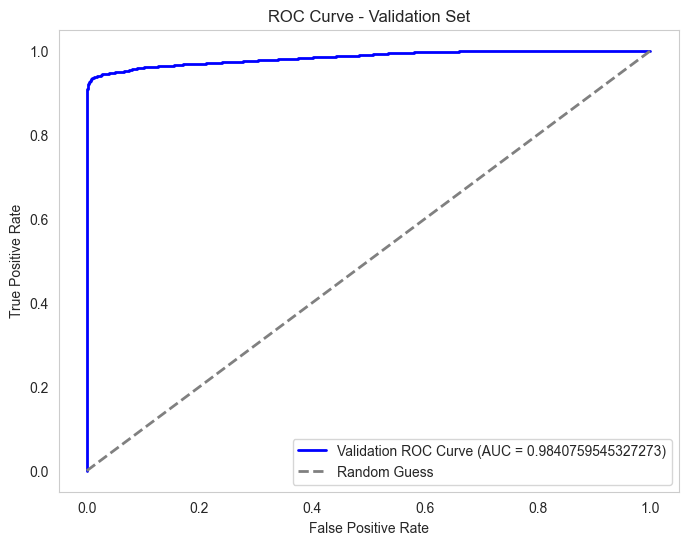

In [137]:
# Plot ROC Curve untuk Validation Set
fpr, tpr, _ = roc_curve(y_val, val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Validation ROC Curve (AUC = {val_auc})")
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [138]:
import joblib

# Simpan model
joblib.dump(final_model, "xgboost_credit_risk.pkl")


['xgboost_credit_risk.pkl']